In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.optimize import minimize
from scipy.stats import kstest, expon
import time
from numba import njit
import pandas as pd
import pickle as pkl
import copy
import random
import importlib
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm, BoundaryNorm
from matplotlib.colors import ListedColormap
import seaborn as sns
from collections import defaultdict
np.set_printoptions(threshold=np.inf)

%cd ..
import ClassGVM
importlib.reload(ClassGVM)
from ClassGVM import logit, der_logit, negloglikelihood_with_grad_single_jit
from ClassGVM import ExponentialHawkesGVM

/Users/sachaquayle/Desktop/hawkes-vm/python/gvm model (article1)/GitHub


In [2]:
%cd simulations

/Users/sachaquayle/Desktop/hawkes-vm/python/gvm model (article1)/GitHub/simulations


# 2-dimensional parameters

## Scenario (HP)

In [126]:
####### Define parameters #######

d = 2
alpha = np.array([[0.2, 0.0],[-0.6,1.2]])
beta = np.array([3.5,2.0])
mu = np.array([0.7,1.0])
alpha_tilde = alpha

In [3]:
####### Simulate data #######

nb_realisations = 25
size = 5000

hawkes = ExponentialHawkesGVM(model='gvm', mu=mu, alpha=alpha, beta=beta, alpha_tilde=alpha)
times = hawkes.simulate(size=size, nb_realisations=nb_realisations)

In [4]:
### Save times ####

output_filename = "results_sim/times_dim2_hp.txt"
with open(output_filename, "w") as f:
    f.write("times = ")
    f.write(f"    {times}")
    f.write("\n\n")

### Under (GVM)

In [5]:
true_params = [mu, alpha, beta, alpha]
hawkes.times = times
hawkes.nb_realisations = 25
hawkes.estimation = true_params
pvals = hawkes.pvalues(nb_iterations=50, av_estimation=False, method='cramervonmises', distribution='expon')
print('Pvalue with true params under gvm', np.mean(pvals))

Pvalue with true params under gvm 0.49633013369941337


In [6]:
####### Estimation procedure #######

# Step 1

hawkes = ExponentialHawkesGVM()
hawkes.fit(times)
estimations_step1 = copy.deepcopy(hawkes.multiple_estimations)

# Step 2

hawkes.test_absence_interactions() 

# Step 3

hawkes.fit(times)
estimations_step3 = copy.deepcopy(hawkes.multiple_estimations)

# Step 4

hawkes.tests_hp_vm()

# Step 5

# by averaging each estimation (to show boxplots of errors)
hawkes.fit(times)
estimations_step5 = copy.deepcopy(hawkes.multiple_estimations)

# by minimising sum of log-likelihoods (for p-values)
hawkes.fit(times, each_realisation=False)
estimation_step5 = copy.deepcopy(hawkes.estimation)

pvalues = hawkes.pvalues(nb_iterations=nb_iterations, distribution='expon', method='cramervonmises', av_estimation=False)

#### Save all estimations

In [25]:
output_filename = "results_sim/scenario_hp_dim2_under_gvm.txt"
with open(output_filename, "w") as f:
    f.write("hp_gvm_estimations_step1 = [\n")
    for mu_est, alpha_est, beta_est, alpha_tilde_est in estimations_step1:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_tilde_est.tolist())})),\n")
    f.write("]\n\n")
    
    f.write("hp_gvm_estimations_step3 = [\n")
    for mu_est, alpha_est, beta_est, alpha_tilde_est in estimations_step3:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_tilde_est.tolist())})),\n")
    f.write("]\n\n")
    
    f.write("hp_gvm_estimations_step5 = [\n")
    for mu_est, alpha_est, beta_est, alpha_tilde_est in estimations_step5:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_tilde_est.tolist())})),\n")
    f.write("]\n\n")

    f.write("hp_gvm_final_estimation = (\n")
    mu_est, alpha_est, beta_est, alpha_tilde_est = estimation_step5
    f.write(f"    np.array({repr(mu_est.tolist())}),\n")
    f.write(f"    np.array({repr(alpha_est.tolist())}),\n")
    f.write(f"    np.array({repr(beta_est.tolist())}),\n")
    f.write(f"    np.array({repr(alpha_tilde_est.tolist())})\n")
    f.write(")\n\n")

    f.write('hp_gvm_interaction_matrix =')
    f.write(f'   np.array({repr(hawkes.alpha_zero_coefficients.tolist())})\n') 
    f.write("\n")

    f.write('hp_gvm_matrix_hp =')
    f.write(f'   np.array({repr(hawkes.equal_coefficients.tolist())})\n') 
    f.write("\n")

    f.write('hp_gvm_matrix_vm =')
    f.write(f'   np.array({repr(hawkes.alpha_tilde_zero_coefficients.tolist())})\n') 
    f.write("\n")

    f.write("hp_gvm_pvalues = np.array(\n")
    f.write(f"{repr(pvalues.tolist())}\n")
    f.write(")\n\n")


    

In [127]:
with open("results_sim/scenario_hp_dim2_under_gvm.txt", "r") as file:
    file_content = file.read()
exec(file_content)

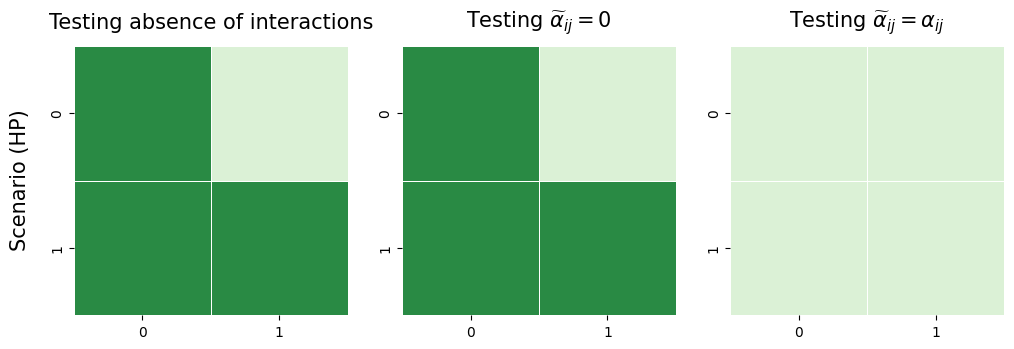

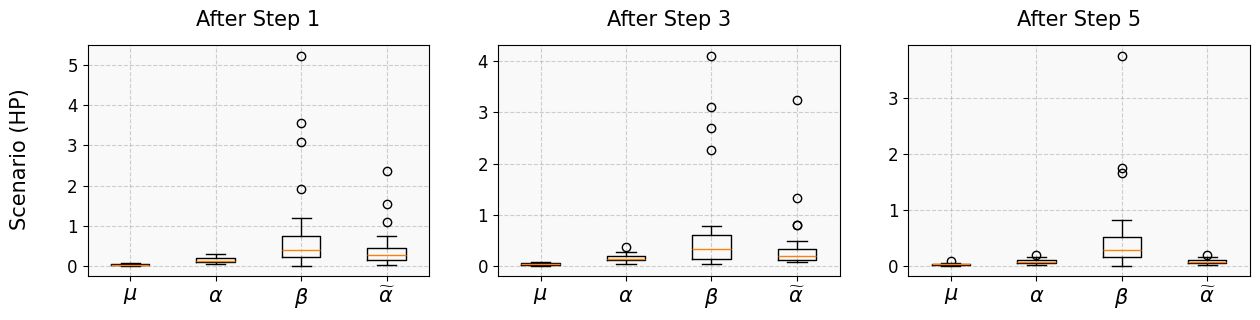

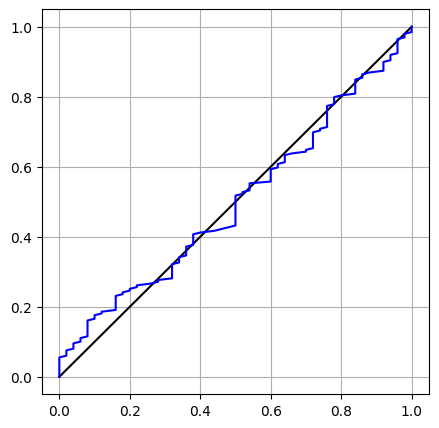

Average p-value: 0.5005002947218723


In [128]:
####### Plot test results #######

fig, axes = plt.subplots(1,3, figsize=(12, 3.5))

colors = ["#ff8a8e", "white", "#00ff2c"]
custom_cmap_real = LinearSegmentedColormap.from_list("custom_cmap", colors)
custom_cmap = ListedColormap(["#dbf1d6", "#e0cbe3","#8c569c", "#298a44"]) 

# Testing interactions 

interaction_test_matrix = hp_gvm_interaction_matrix
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 1, categorical_matrix)  # Undetected zero
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes[0],
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes[0].tick_params(axis='x')
axes[0].tick_params(axis='y')


# Testing VM interactions

test_matrix = hp_gvm_matrix_vm
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, test_matrix), 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, ~test_matrix), 1, categorical_matrix)  # Wrongly detected non-zero
categorical_matrix = np.where(np.logical_and(alpha_tilde != 0, test_matrix), 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(np.logical_and(alpha_tilde != 0,~test_matrix), 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes[1],
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes[1].tick_params(axis='x')
axes[1].tick_params(axis='y')


# Testing HP interactions

test_matrix = hp_gvm_matrix_hp
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == alpha, test_matrix), 0, categorical_matrix)  # Correct equal
categorical_matrix = np.where(np.logical_and(alpha_tilde == alpha, ~test_matrix), 1, categorical_matrix)  # Undetected equal
categorical_matrix = np.where(np.logical_and(alpha_tilde != alpha, test_matrix), 2, categorical_matrix)  # False equal detected
categorical_matrix = np.where(np.logical_and(alpha_tilde != alpha, ~test_matrix), 3, categorical_matrix)  # Correct non-equal

sns.heatmap(
    categorical_matrix,
    ax=axes[2],
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes[2].tick_params(axis='x')
axes[2].tick_params(axis='y')


titlesize = 15
pad = 13
axes[0].set_title(r"Testing absence of interactions", fontsize=titlesize, pad=pad)
axes[1].set_title(r"Testing $\widetilde{\alpha}_{ij} = 0$", fontsize=titlesize, pad=pad)
axes[2].set_title(r"Testing $\widetilde{\alpha}_{ij}=\alpha_{ij} $", fontsize=titlesize,pad=pad)
fig.text(0.08, 0.5,'Scenario (HP)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()


####### Error boxplots after each step #######

def relative_error_norm(estimation, true):
    n = len(true)
    if np.sum(true==0) == n*n:
        return np.linalg.norm(estimation)
    return (np.linalg.norm(estimation-true) / np.linalg.norm(true))
    
def compute_errors(multiple_estimations, mu, alpha, beta, alpha_tilde):
    mu_errors = [relative_error_norm(est[0], mu) for est in multiple_estimations]
    alpha_errors = [relative_error_norm(est[1], alpha) for est in multiple_estimations]
    beta_errors = [relative_error_norm(est[2], beta) for est in multiple_estimations]
    alpha_tilde_errors = [relative_error_norm(est[3], alpha_tilde) for est in multiple_estimations]

    return [mu_errors, alpha_errors, beta_errors, alpha_tilde_errors]

labels = [r'$\mu$', r'$\alpha$', r'$\beta$', r'$\widetilde{\alpha}$']

fig, ax = plt.subplots(1,3, figsize=(15,3))
titlesize = 15
xsize = 15
ysize = 12
pad = 14

data = compute_errors(hp_gvm_estimations_step1, mu, alpha, beta, alpha_tilde)
ax[0].boxplot(data, showfliers=True, tick_labels=labels)
ax[0].set_title('After Step 1')
ax[0].grid(True, linestyle='--', alpha=0.6)
ax[0].set_title('After Step 1', fontsize=titlesize, pad=pad)

data = compute_errors(hp_gvm_estimations_step3, mu, alpha, beta, alpha_tilde)
ax[1].boxplot(data, showfliers=True, tick_labels=labels)
ax[1].set_title('After Step 3')
ax[1].grid(True, linestyle='--', alpha=0.6)
ax[1].set_title('After Step 3', fontsize=titlesize, pad=pad)

data = compute_errors(hp_gvm_estimations_step5, mu, alpha, beta, alpha_tilde)
ax[2].boxplot(data, showfliers=True, tick_labels=labels)
ax[2].set_title('After Step 5')
ax[2].grid(True, linestyle='--', alpha=0.6)
ax[2].set_title('After Step 5', fontsize=titlesize, pad=pad)

for i in range(3):
    ax[i].tick_params(axis='x', labelsize=xsize)
    ax[i].tick_params(axis='y', labelsize=ysize)

for a in ax:
    a.set_facecolor('#f9f9f9')

fig.text(0.08, 0.5,'Scenario (HP)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()


####### P-values #######

nb_iterations = 50 # for resampling

fig,ax=plt.subplots(figsize=(5,5))
nb = 200
y = np.linspace(0, 1, nb)

values = np.array([np.sum(hp_gvm_pvalues <= yk) / nb_iterations for yk in y])

ax.plot(y, y,color='black')
ax.plot(values, y,color='blue')
ax.grid()
plt.show()

print('Average p-value:', np.mean(hp_gvm_pvalues))

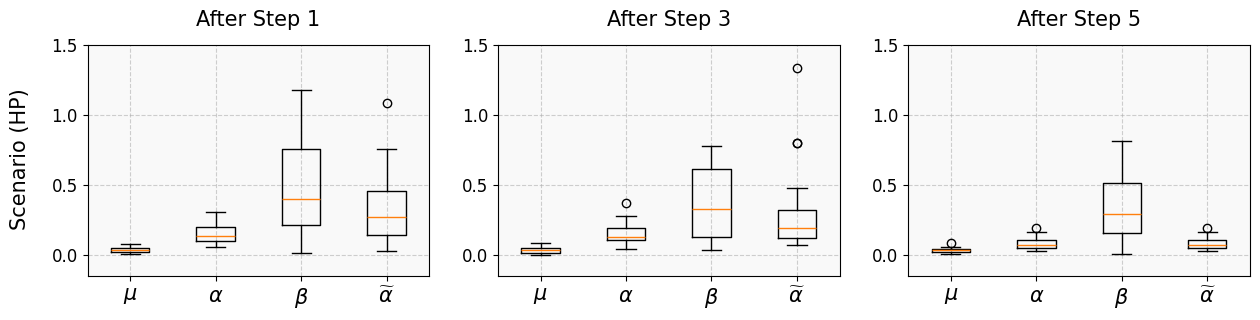

In [130]:
# to rescale boxplots

labels = [r'$\mu$', r'$\alpha$', r'$\beta$', r'$\widetilde{\alpha}$']

fig, ax = plt.subplots(1,3, figsize=(15,3))
titlesize = 15
xsize = 15
ysize = 12
pad = 14
ymax = 1.5

data = compute_errors(hp_gvm_estimations_step1, mu, alpha, beta, alpha_tilde)
ax[0].boxplot(data, showfliers=True, tick_labels=labels)
ax[0].set_title('After Step 1')
ax[0].grid(True, linestyle='--', alpha=0.6)
ax[0].set_title('After Step 1', fontsize=titlesize, pad=pad)
ax[0].set_ylim(-0.15,ymax)

data = compute_errors(hp_gvm_estimations_step3, mu, alpha, beta, alpha_tilde)
ax[1].boxplot(data, showfliers=True, tick_labels=labels)
ax[1].set_title('After Step 3')
ax[1].grid(True, linestyle='--', alpha=0.6)
ax[1].set_title('After Step 3', fontsize=titlesize, pad=pad)
ax[1].set_ylim(-0.15,ymax)

data = compute_errors(hp_gvm_estimations_step5, mu, alpha, beta, alpha_tilde)
ax[2].boxplot(data, showfliers=True, tick_labels=labels)
ax[2].set_title('After Step 5')
ax[2].grid(True, linestyle='--', alpha=0.6)
ax[2].set_title('After Step 5', fontsize=titlesize, pad=pad)
ax[2].set_ylim(-0.15,ymax)


for i in range(3):
    ax[i].tick_params(axis='x', labelsize=xsize)
    ax[i].tick_params(axis='y', labelsize=ysize)

for a in ax:
    a.set_facecolor('#f9f9f9')

fig.text(0.08, 0.5,'Scenario (HP)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()

### Under (HP)

In [21]:
true_params = [mu, alpha, beta]
hawkes_hp = ExponentialHawkesGVM(model='hp')
hawkes_hp.d = d
hawkes_hp.times = times
hawkes_hp.nb_realisations = 25
hawkes_hp.estimation = true_params
pvals = hawkes_hp.pvalues(nb_iterations=50, av_estimation=False, method='cramervonmises', distribution='expon')
print('Pvalue with true params under hp:', np.mean(pvals))

Pvalue with true params under hp: 0.4962934712505617


In [ ]:
hawkes_hp_est = ExponentialHawkesGVM(model='hp')
hawkes_hp_est.fit(times)
hawkes_hp_est.test_sparsity_alpha()
hawkes_hp_est.fit(times, each_realisation=False)

pvalues = hawkes_hp_est.pvalues(nb_iterations=nb_iterations, distribution='expon', method='cramervonmises', av_estimation=False)

#### Save all estimations

In [61]:
output_filename = "results_sim/scenario_hp_dim2_under_hp.txt"
with open(output_filename, "w") as f:
    f.write("hp_hp_estimations_step1 = [\n")
    for mu_est, alpha_est, beta_est in hawkes_hp_est.multiple_estimations:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())})),\n")
    f.write("]\n\n")
    
    f.write("hp_hp_final_estimation = (\n")
    mu_est, alpha_est, beta_est = hawkes_hp_est.estimation
    f.write(f"    np.array({repr(mu_est.tolist())}),\n")
    f.write(f"    np.array({repr(alpha_est.tolist())}),\n")
    f.write(f"    np.array({repr(beta_est.tolist())}),\n")
    f.write(")\n\n")

    f.write('hp_hp_interaction_matrix =')
    f.write(f'   np.array({repr(hawkes_hp_est.alpha_zero_coefficients.tolist())})\n') 
    f.write("\n")

    f.write("hp_hp_pvalues = np.array(\n")
    f.write(f"{repr(pvalues.tolist())}\n")
    f.write(")\n\n")


    

In [131]:
with open("results_sim/scenario_hp_dim2_under_hp.txt", "r") as file:
    file_content = file.read()
exec(file_content)

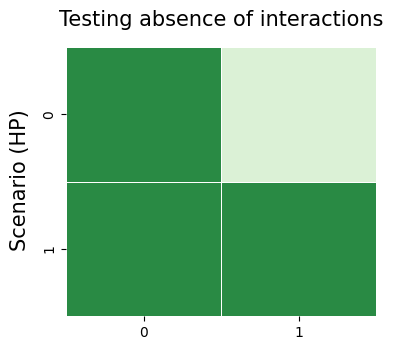

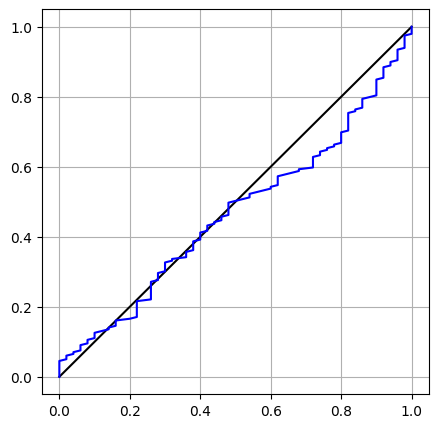

Average p-value: 0.46722081188086245


In [132]:
####### Plot test results #######

fig, axes = plt.subplots( figsize=(4, 3.5))

colors = ["#ff8a8e", "white", "#00ff2c"]
custom_cmap_real = LinearSegmentedColormap.from_list("custom_cmap", colors)
custom_cmap = ListedColormap(["#dbf1d6", "#e0cbe3","#8c569c", "#298a44"]) 

# Testing interactions 

interaction_test_matrix = hp_hp_interaction_matrix
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 1, categorical_matrix)  # Undetected zero
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes,
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes.tick_params(axis='x')
axes.tick_params(axis='y')


titlesize = 15
pad = 15
axes.set_title(r"Testing absence of interactions", fontsize=titlesize, pad=pad)
fig.text(0.01, 0.5,'Scenario (HP)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()



####### P-values #######

nb_iterations = 50 # for resampling

fig,ax=plt.subplots(figsize=(5,5))
nb = 200
y = np.linspace(0, 1, nb)

values = np.array([np.sum(hp_hp_pvalues <= yk) / nb_iterations for yk in y])

ax.plot(y, y,color='black')
ax.plot(values, y,color='blue')
ax.grid()
plt.show()

print('Average p-value:', np.mean(hp_hp_pvalues))

### Under (VM)

In [40]:
true_params = [mu, alpha, beta]
hawkes_vm = ExponentialHawkesGVM(model='vm')
hawkes_vm.d = d
hawkes_vm.times = times
hawkes_vm.nb_realisations = 25
hawkes_vm.estimation = true_params
pvals = hawkes_vm.pvalues(nb_iterations=50, av_estimation=False, method='cramervonmises', distribution='expon')
print('Pvalue with true params under vm:', np.mean(pvals))

Pvalue with true params under vm: 6.536202212137355e-08


In [ ]:
hawkes_vm_est = ExponentialHawkesGVM(model='vm')
hawkes_vm_est.fit(times)
hawkes_vm_est.test_sparsity_alpha()
hawkes_vm_est.fit(times, each_realisation=False)-

pvalues = hawkes_vm_est.pvalues(nb_iterations=nb_iterations, distribution='expon', method='cramervonmises', av_estimation=False)

#### Save all estimations

In [51]:
output_filename = "results_sim/scenario_hp_dim2_under_vm.txt"
with open(output_filename, "w") as f:
    f.write("hp_vm_estimations_step1 = [\n")
    for mu_est, alpha_est, beta_est in hawkes_vm_est.multiple_estimations:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())})),\n")
    f.write("]\n\n")
    
    f.write("hp_vm_final_estimation = (\n")
    mu_est, alpha_est, beta_est = hawkes_vm_est.estimation
    f.write(f"    np.array({repr(mu_est.tolist())}),\n")
    f.write(f"    np.array({repr(alpha_est.tolist())}),\n")
    f.write(f"    np.array({repr(beta_est.tolist())}),\n")
    f.write(")\n\n")

    f.write('hp_vm_interaction_matrix =')
    f.write(f'   np.array({repr(hawkes_vm_est.alpha_zero_coefficients.tolist())})\n') 
    f.write("\n")

    f.write("hp_vm_pvalues = np.array(\n")
    f.write(f"{repr(pvalues.tolist())}\n")
    f.write(")\n\n")


    

In [133]:
with open("results_sim/scenario_hp_dim2_under_vm.txt", "r") as file:
    file_content = file.read()
exec(file_content)

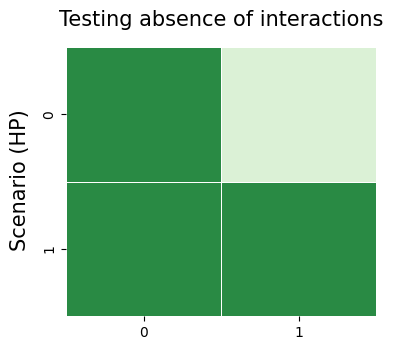

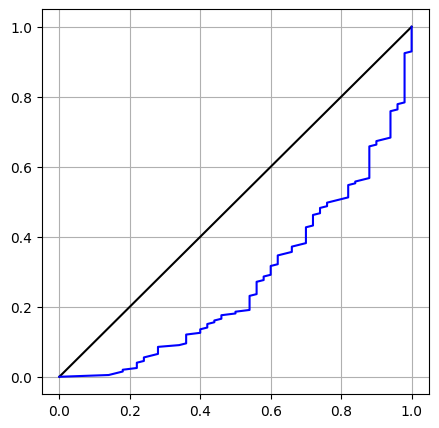

Average p-value: 0.27309901058684244


In [134]:
####### Plot test results #######

fig, axes = plt.subplots( figsize=(4, 3.5))

colors = ["#ff8a8e", "white", "#00ff2c"]
custom_cmap_real = LinearSegmentedColormap.from_list("custom_cmap", colors)
custom_cmap = ListedColormap(["#dbf1d6", "#e0cbe3","#8c569c", "#298a44"]) 

# Testing interactions 

interaction_test_matrix = hp_vm_interaction_matrix
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 1, categorical_matrix)  # Undetected zero
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes,
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes.tick_params(axis='x')
axes.tick_params(axis='y')


titlesize = 15
pad = 15
axes.set_title(r"Testing absence of interactions", fontsize=titlesize, pad=pad)
fig.text(0.01, 0.5,'Scenario (HP)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()



####### P-values #######

nb_iterations = 50 # for resampling

fig,ax=plt.subplots(figsize=(5,5))
nb = 200
y = np.linspace(0, 1, nb)

values = np.array([np.sum(hp_vm_pvalues <= yk) / nb_iterations for yk in y])

ax.plot(y, y,color='black')
ax.plot(values, y,color='blue')
ax.grid()
plt.show()

print('Average p-value:', np.mean(hp_vm_pvalues))

## Scenario (VM)

In [188]:
####### Define parameters #######

d = 2
alpha = np.array([[0.2, 0.0],[-0.6,1.2]])
beta = np.array([3.5,2.0])
mu = np.array([0.7,1.0])
alpha_tilde = np.zeros((d,d))

In [189]:
####### Simulate data #######

nb_realisations = 25
size = 5000

hawkes = ExponentialHawkesGVM(model='gvm', mu=mu, alpha=alpha, beta=beta, alpha_tilde=alpha_tilde)
times = hawkes.simulate(size=size, nb_realisations=nb_realisations)

In [190]:
### Save times ###

output_filename = "results_sim/times_dim2_vm.txt"
with open(output_filename, "w") as f:
    f.write("times = ")
    f.write(f"    {times}")
    f.write("\n\n")

### Under (GVM)

In [90]:
true_params = [mu, alpha, beta, alpha_tilde]
hawkes.times = times
hawkes.nb_realisations = 25
hawkes.estimation = true_params
pvals = hawkes.pvalues(nb_iterations=50, av_estimation=False, method='cramervonmises', distribution='expon')
print('Pvalue with true params under gvm', np.mean(pvals))

Pvalue with true params under gvm 0.5120176762287876


In [83]:
####### Estimation procedure #######

# Step 1

hawkes = ExponentialHawkesGVM()
hawkes.fit(times)
estimations_step1 = copy.deepcopy(hawkes.multiple_estimations)

# Step 2

hawkes.test_absence_interactions() 

# Step 3

hawkes.fit(times)
estimations_step3 = copy.deepcopy(hawkes.multiple_estimations)

# Step 4

hawkes.tests_hp_vm()

# Step 5

# by averaging each estimation (to show boxplots of errors)
hawkes.fit(times)
estimations_step5 = copy.deepcopy(hawkes.multiple_estimations)

# by minimising sum of log-likelihoods (for p-values)
hawkes.fit(times, each_realisation=False)
estimation_step5 = copy.deepcopy(hawkes.estimation)

pvalues = hawkes.pvalues(nb_iterations=nb_iterations, distribution='expon', method='cramervonmises', av_estimation=False)

#### Save all estimations

In [87]:
output_filename = "results_sim/scenario_vm_dim2_under_gvm.txt"
with open(output_filename, "w") as f:
    f.write("vm_gvm_estimations_step1 = [\n")
    for mu_est, alpha_est, beta_est, alpha_tilde_est in estimations_step1:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_tilde_est.tolist())})),\n")
    f.write("]\n\n")
    
    f.write("vm_gvm_estimations_step3 = [\n")
    for mu_est, alpha_est, beta_est, alpha_tilde_est in estimations_step3:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_tilde_est.tolist())})),\n")
    f.write("]\n\n")
    
    f.write("vm_gvm_estimations_step5 = [\n")
    for mu_est, alpha_est, beta_est, alpha_tilde_est in estimations_step5:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_tilde_est.tolist())})),\n")
    f.write("]\n\n")

    f.write("vm_gvm_final_estimation = (\n")
    mu_est, alpha_est, beta_est, alpha_tilde_est = estimation_step5
    f.write(f"    np.array({repr(mu_est.tolist())}),\n")
    f.write(f"    np.array({repr(alpha_est.tolist())}),\n")
    f.write(f"    np.array({repr(beta_est.tolist())}),\n")
    f.write(f"    np.array({repr(alpha_tilde_est.tolist())})\n")
    f.write(")\n\n")

    f.write('vm_gvm_interaction_matrix =')
    f.write(f'   np.array({repr(hawkes.alpha_zero_coefficients.tolist())})\n') 
    f.write("\n")

    f.write('vm_gvm_matrix_hp =')
    f.write(f'   np.array({repr(hawkes.equal_coefficients.tolist())})\n') 
    f.write("\n")

    f.write('vm_gvm_matrix_vm =')
    f.write(f'   np.array({repr(hawkes.alpha_tilde_zero_coefficients.tolist())})\n') 
    f.write("\n")

    f.write("vm_gvm_pvalues = np.array(\n")
    f.write(f"{repr(pvalues.tolist())}\n")
    f.write(")\n\n")


    

In [138]:
with open("results_sim/scenario_vm_dim2_under_gvm.txt", "r") as file:
    file_content = file.read()
exec(file_content)

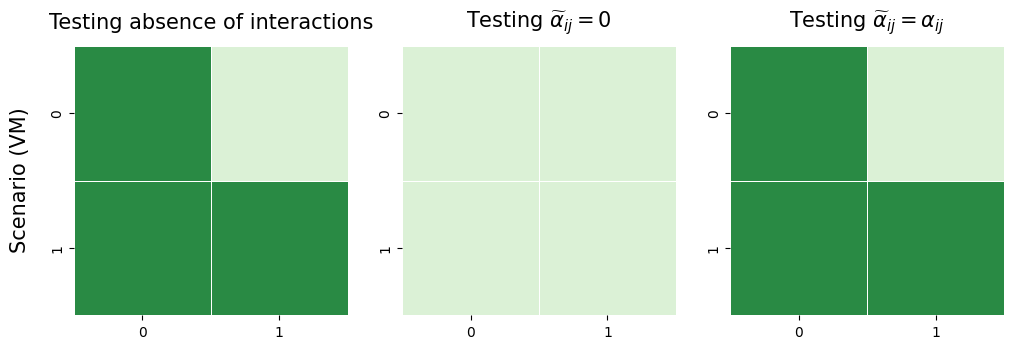

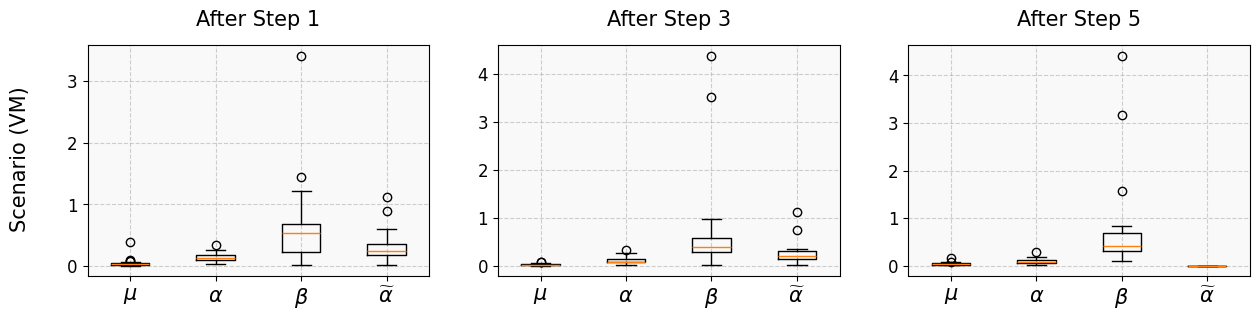

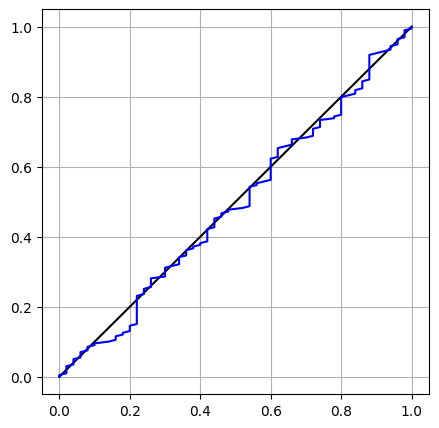

Average p-value: 0.4888093113401382


In [142]:
####### Plot test results #######

fig, axes = plt.subplots(1,3, figsize=(12, 3.5))

colors = ["#ff8a8e", "white", "#00ff2c"]
custom_cmap_real = LinearSegmentedColormap.from_list("custom_cmap", colors)
custom_cmap = ListedColormap(["#dbf1d6", "#e0cbe3","#8c569c", "#298a44"]) 

# Testing interactions 

interaction_test_matrix = vm_gvm_interaction_matrix
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 1, categorical_matrix)  # Undetected zero
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes[0],
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes[0].tick_params(axis='x')
axes[0].tick_params(axis='y')


# Testing VM interactions

test_matrix = vm_gvm_matrix_vm
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, test_matrix), 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, ~test_matrix), 1, categorical_matrix)  # Wrongly detected non-zero
categorical_matrix = np.where(np.logical_and(alpha_tilde != 0, test_matrix), 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(np.logical_and(alpha_tilde != 0,~test_matrix), 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes[1],
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes[1].tick_params(axis='x')
axes[1].tick_params(axis='y')


# Testing HP interactions

test_matrix = vm_gvm_matrix_hp
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == alpha, test_matrix), 0, categorical_matrix)  # Correct equal
categorical_matrix = np.where(np.logical_and(alpha_tilde == alpha, ~test_matrix), 1, categorical_matrix)  # Undetected equal
categorical_matrix = np.where(np.logical_and(alpha_tilde != alpha, test_matrix), 2, categorical_matrix)  # False equal detected
categorical_matrix = np.where(np.logical_and(alpha_tilde != alpha, ~test_matrix), 3, categorical_matrix)  # Correct non-equal

sns.heatmap(
    categorical_matrix,
    ax=axes[2],
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes[2].tick_params(axis='x')
axes[2].tick_params(axis='y')


titlesize = 15
pad = 13
axes[0].set_title(r"Testing absence of interactions", fontsize=titlesize, pad=pad)
axes[1].set_title(r"Testing $\widetilde{\alpha}_{ij} = 0$", fontsize=titlesize, pad=pad)
axes[2].set_title(r"Testing $\widetilde{\alpha}_{ij}=\alpha_{ij} $", fontsize=titlesize,pad=pad)
fig.text(0.08, 0.5,'Scenario (VM)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()


####### Error boxplots after each step #######

def relative_error_norm(estimation, true):
    n = len(true)
    if np.sum(true==0) == n*n:
        return np.linalg.norm(estimation)
    return (np.linalg.norm(estimation-true) / np.linalg.norm(true))
    
def compute_errors(multiple_estimations, mu, alpha, beta, alpha_tilde):
    mu_errors = [relative_error_norm(est[0], mu) for est in multiple_estimations]
    alpha_errors = [relative_error_norm(est[1], alpha) for est in multiple_estimations]
    beta_errors = [relative_error_norm(est[2], beta) for est in multiple_estimations]
    alpha_tilde_errors = [relative_error_norm(est[3], alpha_tilde) for est in multiple_estimations]

    return [mu_errors, alpha_errors, beta_errors, alpha_tilde_errors]

labels = [r'$\mu$', r'$\alpha$', r'$\beta$', r'$\widetilde{\alpha}$']

fig, ax = plt.subplots(1,3, figsize=(15,3))
titlesize = 15
xsize = 15
ysize = 12
pad = 14

data = compute_errors(vm_gvm_estimations_step1, mu, alpha, beta, alpha_tilde)
ax[0].boxplot(data, showfliers=True, tick_labels=labels)
ax[0].set_title('After Step 1')
ax[0].grid(True, linestyle='--', alpha=0.6)
ax[0].set_title('After Step 1', fontsize=titlesize, pad=pad)

data = compute_errors(vm_gvm_estimations_step3, mu, alpha, beta, alpha_tilde)
ax[1].boxplot(data, showfliers=True, tick_labels=labels)
ax[1].set_title('After Step 3')
ax[1].grid(True, linestyle='--', alpha=0.6)
ax[1].set_title('After Step 3', fontsize=titlesize, pad=pad)

data = compute_errors(vm_gvm_estimations_step5, mu, alpha, beta, alpha_tilde)
ax[2].boxplot(data, showfliers=True, tick_labels=labels)
ax[2].set_title('After Step 5')
ax[2].grid(True, linestyle='--', alpha=0.6)
ax[2].set_title('After Step 5', fontsize=titlesize, pad=pad)

for i in range(3):
    ax[i].tick_params(axis='x', labelsize=xsize)
    ax[i].tick_params(axis='y', labelsize=ysize)

for a in ax:
    a.set_facecolor('#f9f9f9')

fig.text(0.08, 0.5,'Scenario (VM)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()


####### P-values #######

nb_iterations = 50 # for resampling

fig,ax=plt.subplots(figsize=(5,5))
nb = 200
y = np.linspace(0, 1, nb)

values = np.array([np.sum(vm_gvm_pvalues <= yk) / nb_iterations for yk in y])

ax.plot(y, y,color='black')
ax.plot(values, y,color='blue')
ax.grid()
plt.show()

print('Average p-value:', np.mean(vm_gvm_pvalues))

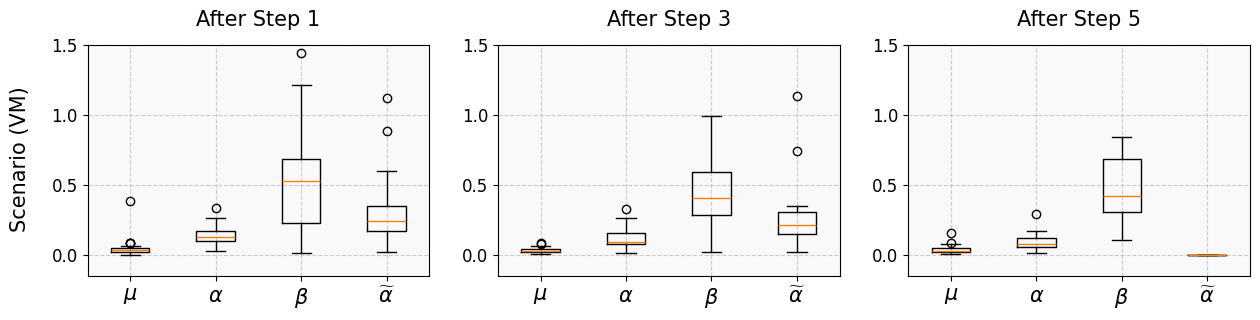

In [143]:
# to rescale boxplots

labels = [r'$\mu$', r'$\alpha$', r'$\beta$', r'$\widetilde{\alpha}$']

fig, ax = plt.subplots(1,3, figsize=(15,3))
titlesize = 15
xsize = 15
ysize = 12
pad = 14
ymax = 1.5

data = compute_errors(vm_gvm_estimations_step1, mu, alpha, beta, alpha_tilde)
ax[0].boxplot(data, showfliers=True, tick_labels=labels)
ax[0].set_title('After Step 1')
ax[0].grid(True, linestyle='--', alpha=0.6)
ax[0].set_title('After Step 1', fontsize=titlesize, pad=pad)
ax[0].set_ylim(-0.15,ymax)

data = compute_errors(vm_gvm_estimations_step3, mu, alpha, beta, alpha_tilde)
ax[1].boxplot(data, showfliers=True, tick_labels=labels)
ax[1].set_title('After Step 3')
ax[1].grid(True, linestyle='--', alpha=0.6)
ax[1].set_title('After Step 3', fontsize=titlesize, pad=pad)
ax[1].set_ylim(-0.15,ymax)

data = compute_errors(vm_gvm_estimations_step5, mu, alpha, beta, alpha_tilde)
ax[2].boxplot(data, showfliers=True, tick_labels=labels)
ax[2].set_title('After Step 5')
ax[2].grid(True, linestyle='--', alpha=0.6)
ax[2].set_title('After Step 5', fontsize=titlesize, pad=pad)
ax[2].set_ylim(-0.15,ymax)


for i in range(3):
    ax[i].tick_params(axis='x', labelsize=xsize)
    ax[i].tick_params(axis='y', labelsize=ysize)

for a in ax:
    a.set_facecolor('#f9f9f9')

fig.text(0.08, 0.5,'Scenario (VM)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()

### Under (HP)

In [91]:
true_params = [mu, alpha, beta]
hawkes_hp = ExponentialHawkesGVM(model='hp')
hawkes_hp.d = d
hawkes_hp.times = times
hawkes_hp.nb_realisations = 25
hawkes_hp.estimation = true_params
pvals = hawkes_hp.pvalues(nb_iterations=50, av_estimation=False, method='cramervonmises', distribution='expon')
print('Pvalue with true params under hp:', np.mean(pvals))

Pvalue with true params under hp: 1.309661255000094e-08


In [ ]:
hawkes_hp_est = ExponentialHawkesGVM(model='hp')
hawkes_hp_est.fit(times)
hawkes_hp_est.test_sparsity_alpha()
hawkes_hp_est.fit(times, each_realisation=False)
pvalues = hawkes_hp_est.pvalues(nb_iterations=nb_iterations, distribution='expon', method='cramervonmises', av_estimation=False)


#### Save all estimations

In [93]:
output_filename = "results_sim/scenario_vm_dim2_under_hp.txt"
with open(output_filename, "w") as f:
    f.write("vm_hp_estimations_step1 = [\n")
    for mu_est, alpha_est, beta_est in hawkes_hp_est.multiple_estimations:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())})),\n")
    f.write("]\n\n")
    
    f.write("vm_hp_final_estimation = (\n")
    mu_est, alpha_est, beta_est = hawkes_hp_est.estimation
    f.write(f"    np.array({repr(mu_est.tolist())}),\n")
    f.write(f"    np.array({repr(alpha_est.tolist())}),\n")
    f.write(f"    np.array({repr(beta_est.tolist())}),\n")
    f.write(")\n\n")

    f.write('vm_hp_interaction_matrix =')
    f.write(f'   np.array({repr(hawkes_hp_est.alpha_zero_coefficients.tolist())})\n') 
    f.write("\n")

    f.write("vm_hp_pvalues = np.array(\n")
    f.write(f"{repr(pvalues.tolist())}\n")
    f.write(")\n\n")


    

In [144]:
with open("results_sim/scenario_vm_dim2_under_hp.txt", "r") as file:
    file_content = file.read()
exec(file_content)

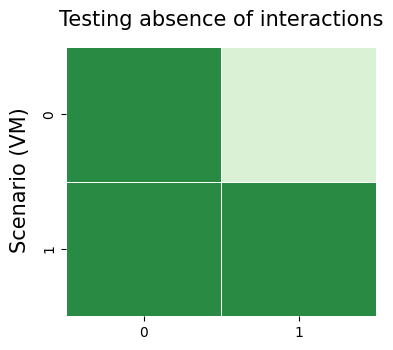

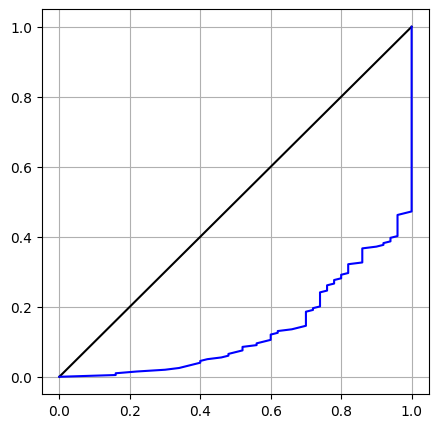

Average p-value: 0.1322369415951959


In [145]:
####### Plot test results #######

fig, axes = plt.subplots( figsize=(4, 3.5))

colors = ["#ff8a8e", "white", "#00ff2c"]
custom_cmap_real = LinearSegmentedColormap.from_list("custom_cmap", colors)
custom_cmap = ListedColormap(["#dbf1d6", "#e0cbe3","#8c569c", "#298a44"]) 

# Testing interactions 

interaction_test_matrix = vm_hp_interaction_matrix
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 1, categorical_matrix)  # Undetected zero
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes,
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes.tick_params(axis='x')
axes.tick_params(axis='y')


titlesize = 15
pad = 15
axes.set_title(r"Testing absence of interactions", fontsize=titlesize, pad=pad)
fig.text(0.01, 0.5,'Scenario (VM)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()



####### P-values #######

nb_iterations = 50 # for resampling

fig,ax=plt.subplots(figsize=(5,5))
nb = 200
y = np.linspace(0, 1, nb)

values = np.array([np.sum(vm_hp_pvalues <= yk) / nb_iterations for yk in y])

ax.plot(y, y,color='black')
ax.plot(values, y,color='blue')
ax.grid()
plt.show()

print('Average p-value:', np.mean(vm_hp_pvalues))

### Under (VM)

In [96]:
true_params = [mu, alpha, beta]
hawkes_vm = ExponentialHawkesGVM(model='vm')
hawkes_vm.d = d
hawkes_vm.times = times
hawkes_vm.nb_realisations = 25
hawkes_vm.estimation = true_params
pvals = hawkes_vm.pvalues(nb_iterations=50, av_estimation=False, method='cramervonmises', distribution='expon')
print('Pvalue with true params under vm:', np.mean(pvals))

Pvalue with true params under vm: 0.48353269051205366


In [ ]:
hawkes_vm_est = ExponentialHawkesGVM(model='vm')
hawkes_vm_est.fit(times)
hawkes_vm_est.test_sparsity_alpha()
hawkes_vm_est.fit(times, each_realisation=False)

pvalues = hawkes_vm_est.pvalues(nb_iterations=nb_iterations, distribution='expon', method='cramervonmises', av_estimation=False)

#### Save all estimations

In [98]:
output_filename = "results_sim/scenario_vm_dim2_under_vm.txt"
with open(output_filename, "w") as f:
    f.write("vm_vm_estimations_step1 = [\n")
    for mu_est, alpha_est, beta_est in hawkes_vm_est.multiple_estimations:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())})),\n")
    f.write("]\n\n")
    
    f.write("vm_vm_final_estimation = (\n")
    mu_est, alpha_est, beta_est = hawkes_vm_est.estimation
    f.write(f"    np.array({repr(mu_est.tolist())}),\n")
    f.write(f"    np.array({repr(alpha_est.tolist())}),\n")
    f.write(f"    np.array({repr(beta_est.tolist())}),\n")
    f.write(")\n\n")

    f.write('vm_vm_interaction_matrix =')
    f.write(f'   np.array({repr(hawkes_vm_est.alpha_zero_coefficients.tolist())})\n') 
    f.write("\n")

    f.write("vm_vm_pvalues = np.array(\n")
    f.write(f"{repr(pvalues.tolist())}\n")
    f.write(")\n\n")


    

In [146]:
with open("results_sim/scenario_vm_dim2_under_vm.txt", "r") as file:
    file_content = file.read()
exec(file_content)

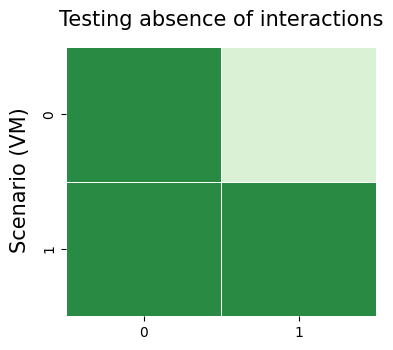

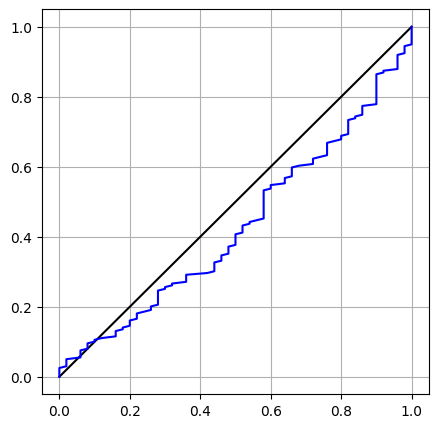

Average p-value: 0.43041257504819763


In [147]:
####### Plot test results #######

fig, axes = plt.subplots( figsize=(4, 3.5))

colors = ["#ff8a8e", "white", "#00ff2c"]
custom_cmap_real = LinearSegmentedColormap.from_list("custom_cmap", colors)
custom_cmap = ListedColormap(["#dbf1d6", "#e0cbe3","#8c569c", "#298a44"]) 

# Testing interactions 

interaction_test_matrix = vm_vm_interaction_matrix
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 1, categorical_matrix)  # Undetected zero
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes,
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes.tick_params(axis='x')
axes.tick_params(axis='y')


titlesize = 15
pad = 15
axes.set_title(r"Testing absence of interactions", fontsize=titlesize, pad=pad)
fig.text(0.01, 0.5,'Scenario (VM)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()



####### P-values #######

nb_iterations = 50 # for resampling

fig,ax=plt.subplots(figsize=(5,5))
nb = 200
y = np.linspace(0, 1, nb)

values = np.array([np.sum(vm_vm_pvalues <= yk) / nb_iterations for yk in y])

ax.plot(y, y,color='black')
ax.plot(values, y,color='blue')
ax.grid()
plt.show()

print('Average p-value:', np.mean(vm_vm_pvalues))

# 10-dimensional parameters

## Scenario (HP)

In [2]:
####### Define parameters #######

d = 10

mu = np.array([1.0, 1.3, 1.2, 0.8, 0.5, 0.3, 1.1, 1.0, 0.3, 1.5])

alpha = np.array( [ [0.5, 0.0, 0.2, -0.8, 0.5, 0.7, 0.0, 0.0, 0.0, 0.0],
                    [1.0, -0.5, -0.2, 0.0, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0],
                    [0.2, -0.9, 0.7, 0.1, -0.1, 0.3, 0.0, 0.0, 0.0, 0.0],
                    [-0.4, 0.0, 1.2, -0.8, 0.2, 0.2, 0.0, 0.0, 0.0, 0.0],
                    [1.2, 0.3, 0.0, 0.0, 0.7, 0.0, 0.0, 0.0, 0.0, 0.0],
                    [0.0, -0.1, 1.0, -0.8, 0.1, 0.2, 0.0, 0.0, 0.0, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.5, -0.1, -0.2, -0.1, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.5, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.3, 0.3, 0.5, -0.1, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.4, 0.6] ])

beta = np.array([6.0, 3.0, 2.2, 3.6, 6.0, 1.4, 2.4, 2.0, 1.6, 2.4])

alpha_tilde = alpha

In [102]:
####### Simulate data #######

nb_realisations = 25
size = 10000

hawkes = ExponentialHawkesGVM(model='gvm', mu=mu, alpha=alpha, beta=beta, alpha_tilde=alpha)
times = hawkes.simulate(size=size, nb_realisations=nb_realisations)

In [103]:
### Save times ####

output_filename = "results_sim/times_dim10_hp.txt"
with open(output_filename, "w") as f:
    f.write("times = ")
    f.write(f"    {times}")
    f.write("\n\n")

### Under (GVM)

In [105]:
####### Estimation procedure #######

# Step 1

hawkes = ExponentialHawkesGVM()
hawkes.fit(times)
estimations_step1 = copy.deepcopy(hawkes.multiple_estimations)

# Step 2

hawkes.test_absence_interactions() 

# Step 3

hawkes.fit(times)
estimations_step3 = copy.deepcopy(hawkes.multiple_estimations)

# Step 4

hawkes.tests_hp_vm()

# Step 5

# by averaging each estimation (to show boxplots of errors)
hawkes.fit(times)
estimations_step5 = copy.deepcopy(hawkes.multiple_estimations)

# by minimising sum of log-likelihoods (for p-values)
hawkes.fit(times, each_realisation=False)
estimation_step5 = copy.deepcopy(hawkes.estimation)

pvalues = hawkes.pvalues(nb_iterations=nb_iterations, distribution='expon', method='cramervonmises', av_estimation=False)

#### Save all estimations

In [111]:
output_filename = "results_sim/scenario_hp_dim10_under_gvm.txt"
with open(output_filename, "w") as f:
    f.write("hp_gvm_estimations_step1 = [\n")
    for mu_est, alpha_est, beta_est, alpha_tilde_est in estimations_step1:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_tilde_est.tolist())})),\n")
    f.write("]\n\n")
    
    f.write("hp_gvm_estimations_step3 = [\n")
    for mu_est, alpha_est, beta_est, alpha_tilde_est in estimations_step3:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_tilde_est.tolist())})),\n")
    f.write("]\n\n")
    
    f.write("hp_gvm_estimations_step5 = [\n")
    for mu_est, alpha_est, beta_est, alpha_tilde_est in estimations_step5:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_tilde_est.tolist())})),\n")
    f.write("]\n\n")

    f.write("hp_gvm_final_estimation = (\n")
    mu_est, alpha_est, beta_est, alpha_tilde_est = estimation_step5
    f.write(f"    np.array({repr(mu_est.tolist())}),\n")
    f.write(f"    np.array({repr(alpha_est.tolist())}),\n")
    f.write(f"    np.array({repr(beta_est.tolist())}),\n")
    f.write(f"    np.array({repr(alpha_tilde_est.tolist())})\n")
    f.write(")\n\n")

    f.write('hp_gvm_interaction_matrix =')
    f.write(f'   np.array({repr(hawkes.alpha_zero_coefficients.tolist())})\n') 
    f.write("\n")

    f.write('hp_gvm_matrix_hp =')
    f.write(f'   np.array({repr(hawkes.equal_coefficients.tolist())})\n') 
    f.write("\n")

    f.write('hp_gvm_matrix_vm =')
    f.write(f'   np.array({repr(hawkes.alpha_tilde_zero_coefficients.tolist())})\n') 
    f.write("\n")

    f.write("hp_gvm_pvalues = np.array(\n")
    f.write(f"{repr(pvalues.tolist())}\n")
    f.write(")\n\n")


    

In [4]:
with open("results_sim/scenario_hp_dim10_under_gvm.txt", "r") as file:
    file_content = file.read()
exec(file_content)

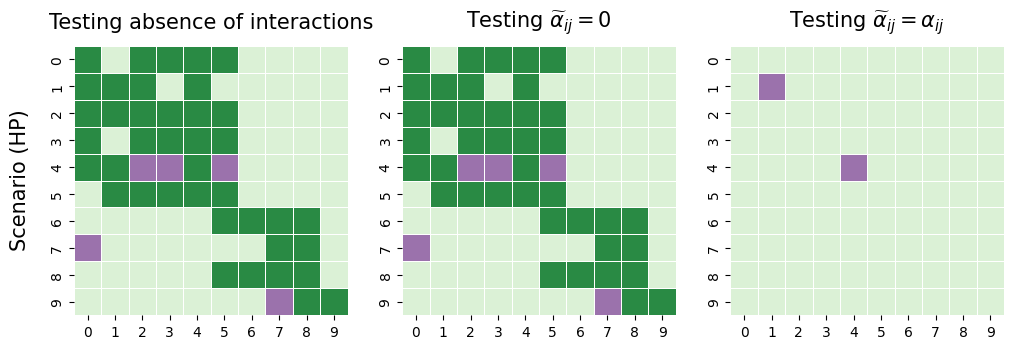

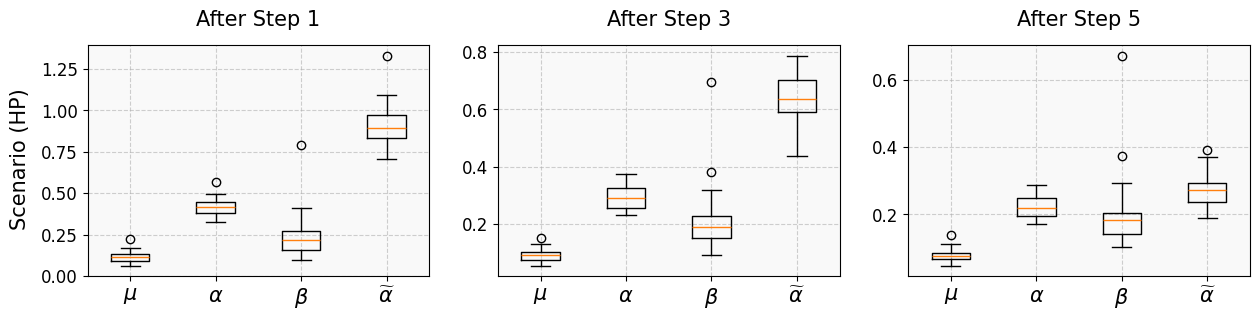

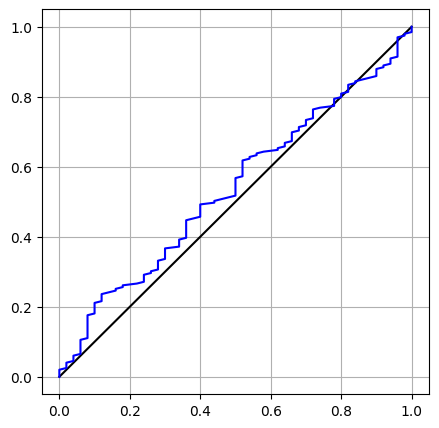

Average p-value: 0.5368279973258427


In [7]:
####### Plot test results #######

fig, axes = plt.subplots(1,3, figsize=(12, 3.5))

colors = ["#ff8a8e", "white", "#00ff2c"]
custom_cmap_real = LinearSegmentedColormap.from_list("custom_cmap", colors)
custom_cmap = ListedColormap(["#dbf1d6","#9b72ac", "#d9c2de", "#298a44"]) 

# Testing interactions 

interaction_test_matrix = ~hp_gvm_interaction_matrix
interactions = ~np.logical_and(alpha_tilde==0, alpha==0)

categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(~interactions, ~interaction_test_matrix), 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(~interactions, interaction_test_matrix), 1, categorical_matrix)  # Undetected zero
categorical_matrix = np.where(np.logical_and(interactions, ~interaction_test_matrix), 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(np.logical_and(interactions, interaction_test_matrix), 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes[0],
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes[0].tick_params(axis='x')
axes[0].tick_params(axis='y')


# Testing VM interactions

test_matrix = hp_gvm_matrix_vm
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, test_matrix), 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, ~test_matrix), 1, categorical_matrix)  # Wrongly detected non-zero
categorical_matrix = np.where(np.logical_and(alpha_tilde != 0, test_matrix), 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(np.logical_and(alpha_tilde != 0,~test_matrix), 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes[1],
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes[1].tick_params(axis='x')
axes[1].tick_params(axis='y')


# Testing HP interactions

test_matrix = hp_gvm_matrix_hp
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == alpha, test_matrix), 0, categorical_matrix)  # Correct equal
categorical_matrix = np.where(np.logical_and(alpha_tilde == alpha, ~test_matrix), 1, categorical_matrix)  # Undetected equal
categorical_matrix = np.where(np.logical_and(alpha_tilde != alpha, test_matrix), 2, categorical_matrix)  # False equal detected
categorical_matrix = np.where(np.logical_and(alpha_tilde != alpha, ~test_matrix), 3, categorical_matrix)  # Correct non-equal

sns.heatmap(
    categorical_matrix,
    ax=axes[2],
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes[2].tick_params(axis='x')
axes[2].tick_params(axis='y')


titlesize = 15
pad = 13
axes[0].set_title(r"Testing absence of interactions", fontsize=titlesize, pad=pad)
axes[1].set_title(r"Testing $\widetilde{\alpha}_{ij} = 0$", fontsize=titlesize, pad=pad)
axes[2].set_title(r"Testing $\widetilde{\alpha}_{ij}=\alpha_{ij} $", fontsize=titlesize,pad=pad)
fig.text(0.08, 0.5,'Scenario (HP)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()


####### Error boxplots after each step #######

def relative_error_norm(estimation, true):
    n = len(true)
    if np.sum(true==0) == n*n:
        return np.linalg.norm(estimation)
    return (np.linalg.norm(estimation-true) / np.linalg.norm(true))
    
def compute_errors(multiple_estimations, mu, alpha, beta, alpha_tilde):
    mu_errors = [relative_error_norm(est[0], mu) for est in multiple_estimations]
    alpha_errors = [relative_error_norm(est[1], alpha) for est in multiple_estimations]
    beta_errors = [relative_error_norm(est[2], beta) for est in multiple_estimations]
    alpha_tilde_errors = [relative_error_norm(est[3], alpha_tilde) for est in multiple_estimations]

    return [mu_errors, alpha_errors, beta_errors, alpha_tilde_errors]

labels = [r'$\mu$', r'$\alpha$', r'$\beta$', r'$\widetilde{\alpha}$']

fig, ax = plt.subplots(1,3, figsize=(15,3))
titlesize = 15
xsize = 15
ysize = 12
pad = 14

data = compute_errors(hp_gvm_estimations_step1, mu, alpha, beta, alpha_tilde)
ax[0].boxplot(data, showfliers=True, tick_labels=labels)
ax[0].set_title('After Step 1')
ax[0].grid(True, linestyle='--', alpha=0.6)
ax[0].set_title('After Step 1', fontsize=titlesize, pad=pad)

data = compute_errors(hp_gvm_estimations_step3, mu, alpha, beta, alpha_tilde)
ax[1].boxplot(data, showfliers=True, tick_labels=labels)
ax[1].set_title('After Step 3')
ax[1].grid(True, linestyle='--', alpha=0.6)
ax[1].set_title('After Step 3', fontsize=titlesize, pad=pad)

data = compute_errors(hp_gvm_estimations_step5, mu, alpha, beta, alpha_tilde)
ax[2].boxplot(data, showfliers=True, tick_labels=labels)
ax[2].set_title('After Step 5')
ax[2].grid(True, linestyle='--', alpha=0.6)
ax[2].set_title('After Step 5', fontsize=titlesize, pad=pad)

for i in range(3):
    ax[i].tick_params(axis='x', labelsize=xsize)
    ax[i].tick_params(axis='y', labelsize=ysize)

for a in ax:
    a.set_facecolor('#f9f9f9')

fig.text(0.08, 0.5,'Scenario (HP)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()


####### P-values #######

nb_iterations = 50 # for resampling

fig,ax=plt.subplots(figsize=(5,5))
nb = 200
y = np.linspace(0, 1, nb)

values = np.array([np.sum(hp_gvm_pvalues <= yk) / nb_iterations for yk in y])

ax.plot(y, y,color='black')
ax.plot(values, y,color='blue')
ax.grid()
plt.show()

print('Average p-value:', np.mean(hp_gvm_pvalues))

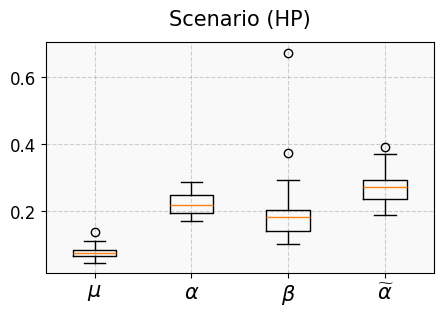

In [231]:
# just Step 5

labels = [r'$\mu$', r'$\alpha$', r'$\beta$', r'$\widetilde{\alpha}$']

fig, ax = plt.subplots(figsize=(5,3))
titlesize = 15
xsize = 15
ysize = 12
pad = 14

data = compute_errors(hp_gvm_estimations_step5, mu, alpha, beta, alpha_tilde)
ax.boxplot(data, showfliers=True, tick_labels=labels)
ax.set_title('After Step 5')
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_title('After Step 5', fontsize=titlesize, pad=pad)

ax.tick_params(axis='x', labelsize=xsize)
ax.tick_params(axis='y', labelsize=ysize)

ax.set_facecolor('#f9f9f9')
plt.title('Scenario (HP)',fontsize=15,pad=12)
plt.show()

### Under (HP)

In [ ]:
hawkes_hp_est = ExponentialHawkesGVM(model='hp')
hawkes_hp_est.fit(times)
hawkes_hp_est.test_sparsity_alpha()
hawkes_hp_est.fit(times, each_realisation=False)

pvalues = hawkes_hp_est.pvalues(nb_iterations=nb_iterations, distribution='expon', method='cramervonmises', av_estimation=False)

#### Save all estimations

In [119]:
output_filename = "results_sim/scenario_hp_dim10_under_hp.txt"
with open(output_filename, "w") as f:
    f.write("hp_hp_estimations_step1 = [\n")
    for mu_est, alpha_est, beta_est in hawkes_hp_est.multiple_estimations:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())})),\n")
    f.write("]\n\n")
    
    f.write("hp_hp_final_estimation = (\n")
    mu_est, alpha_est, beta_est = hawkes_hp_est.estimation
    f.write(f"    np.array({repr(mu_est.tolist())}),\n")
    f.write(f"    np.array({repr(alpha_est.tolist())}),\n")
    f.write(f"    np.array({repr(beta_est.tolist())}),\n")
    f.write(")\n\n")

    f.write('hp_hp_interaction_matrix =')
    f.write(f'   np.array({repr(hawkes_hp_est.alpha_zero_coefficients.tolist())})\n') 
    f.write("\n")

    f.write("hp_hp_pvalues = np.array(\n")
    f.write(f"{repr(pvalues.tolist())}\n")
    f.write(")\n\n")


    

In [217]:
with open("results_sim/scenario_hp_dim10_under_hp.txt", "r") as file:
    file_content = file.read()
exec(file_content)

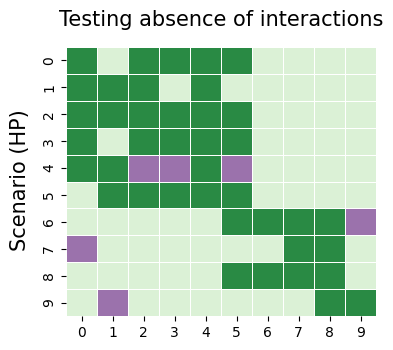

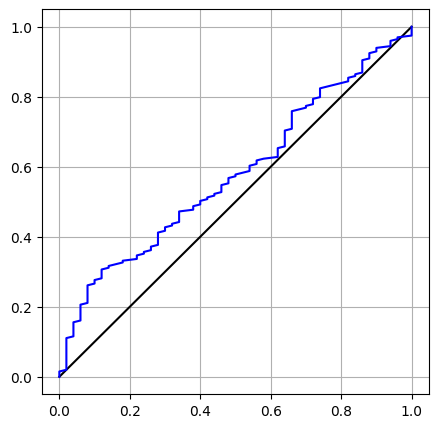

Average p-value: 0.5784927223855557


In [218]:
####### Plot test results #######

fig, axes = plt.subplots( figsize=(4, 3.5))

colors = ["#ff8a8e", "white", "#00ff2c"]
custom_cmap_real = LinearSegmentedColormap.from_list("custom_cmap", colors)
custom_cmap = ListedColormap(["#dbf1d6","#9b72ac", "#d9c2de", "#298a44"]) 

# Testing interactions 

interaction_test_matrix = hp_hp_interaction_matrix
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 1, categorical_matrix)  # Undetected zero
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes,
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes.tick_params(axis='x')
axes.tick_params(axis='y')


titlesize = 15
pad = 15
axes.set_title(r"Testing absence of interactions", fontsize=titlesize, pad=pad)
fig.text(0.01, 0.5,'Scenario (HP)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()



####### P-values #######

nb_iterations = 50 # for resampling

fig,ax=plt.subplots(figsize=(5,5))
nb = 200
y = np.linspace(0, 1, nb)

values = np.array([np.sum(hp_hp_pvalues <= yk) / nb_iterations for yk in y])

ax.plot(y, y,color='black')
ax.plot(values, y,color='blue')
ax.grid()
plt.show()

print('Average p-value:', np.mean(hp_hp_pvalues))

### Under (VM)

In [164]:
hawkes_vm_est = ExponentialHawkesGVM(model='vm')
hawkes_vm_est.fit(times)
hawkes_vm_est.test_sparsity_alpha()
hawkes_vm_est.fit(times, each_realisation=False)
pvalues = hawkes_vm_est.pvalues(nb_iterations=nb_iterations, distribution='expon', method='cramervonmises', av_estimation=False)

#### Save all estimations

In [176]:
output_filename = "results_sim/scenario_hp_dim10_under_vm.txt"
with open(output_filename, "w") as f:
    f.write("hp_vm_estimations_step1 = [\n")
    for mu_est, alpha_est, beta_est in hawkes_vm_est.multiple_estimations:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())})),\n")
    f.write("]\n\n")
    
    f.write("hp_vm_final_estimation = (\n")
    mu_est, alpha_est, beta_est = hawkes_vm_est.estimation
    f.write(f"    np.array({repr(mu_est.tolist())}),\n")
    f.write(f"    np.array({repr(alpha_est.tolist())}),\n")
    f.write(f"    np.array({repr(beta_est.tolist())}),\n")
    f.write(")\n\n")

    f.write('hp_vm_interaction_matrix =')
    f.write(f'   np.array({repr(hawkes_vm_est.alpha_zero_coefficients.tolist())})\n') 
    f.write("\n")

    f.write("hp_vm_pvalues = np.array(\n")
    f.write(f"{repr(pvalues.tolist())}\n")
    f.write(")\n\n")


    

In [219]:
with open("results_sim/scenario_hp_dim10_under_vm.txt", "r") as file:
    file_content = file.read()
exec(file_content)

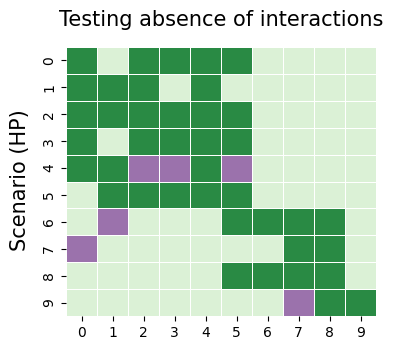

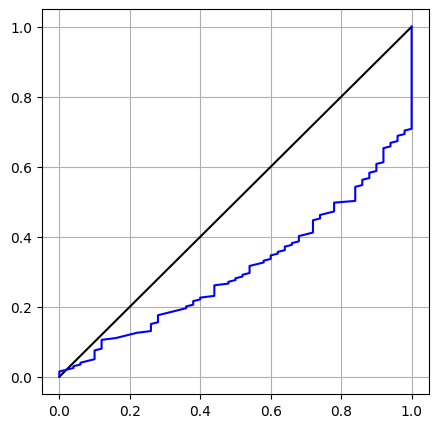

Average p-value: 0.30783348512453945


In [220]:
####### Plot test results #######

fig, axes = plt.subplots( figsize=(4, 3.5))

colors = ["#ff8a8e", "white", "#00ff2c"]
custom_cmap_real = LinearSegmentedColormap.from_list("custom_cmap", colors)
custom_cmap = ListedColormap(["#dbf1d6","#9b72ac", "#d9c2de", "#298a44"]) 

# Testing interactions 

interaction_test_matrix = hp_vm_interaction_matrix
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 1, categorical_matrix)  # Undetected zero
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes,
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes.tick_params(axis='x')
axes.tick_params(axis='y')


titlesize = 15
pad = 15
axes.set_title(r"Testing absence of interactions", fontsize=titlesize, pad=pad)
fig.text(0.01, 0.5,'Scenario (HP)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()



####### P-values #######

nb_iterations = 50 # for resampling

fig,ax=plt.subplots(figsize=(5,5))
nb = 200
y = np.linspace(0, 1, nb)

values = np.array([np.sum(hp_vm_pvalues <= yk) / nb_iterations for yk in y])

ax.plot(y, y,color='black')
ax.plot(values, y,color='blue')
ax.grid()
plt.show()

print('Average p-value:', np.mean(hp_vm_pvalues))

## Scenario (VM)

In [232]:
####### Define parameters #######

d = 10

mu = np.array([1.0, 1.3, 1.2, 0.8, 0.5, 0.3, 1.1, 1.0, 0.3, 1.5])

alpha = np.array( [ [0.5, 0.0, 0.2, -0.8, 0.5, 0.7, 0.0, 0.0, 0.0, 0.0],
                    [1.0, -0.5, -0.2, 0.0, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0],
                    [0.2, -0.9, 0.7, 0.1, -0.1, 0.3, 0.0, 0.0, 0.0, 0.0],
                    [-0.4, 0.0, 1.2, -0.8, 0.2, 0.2, 0.0, 0.0, 0.0, 0.0],
                    [1.2, 0.3, 0.0, 0.0, 0.7, 0.0, 0.0, 0.0, 0.0, 0.0],
                    [0.0, -0.1, 1.0, -0.8, 0.1, 0.2, 0.0, 0.0, 0.0, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.5, -0.1, -0.2, -0.1, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.5, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.3, 0.3, 0.5, -0.1, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.4, 0.6] ])

beta = np.array([6.0, 3.0, 2.2, 3.6, 6.0, 1.4, 2.4, 2.0, 1.6, 2.4])

alpha_tilde = np.zeros((d,d))

In [203]:
####### Simulate data #######

nb_realisations = 25
size = 10000

hawkes = ExponentialHawkesGVM(model='gvm', mu=mu, alpha=alpha, beta=beta, alpha_tilde=alpha_tilde)
times = hawkes.simulate(size=size, nb_realisations=nb_realisations)

In [204]:
### Save times ####

output_filename = "times_dim10_vm.txt"
with open(output_filename, "w") as f:
    f.write("times = ")
    f.write(f"    {times}")
    f.write("\n\n")

### Under (GVM)

In [206]:
####### Estimation procedure #######

# Step 1

hawkes = ExponentialHawkesGVM()
hawkes.fit(times)
estimations_step1 = copy.deepcopy(hawkes.multiple_estimations)

# Step 2

hawkes.test_absence_interactions() 

# Step 3

hawkes.fit(times)
estimations_step3 = copy.deepcopy(hawkes.multiple_estimations)

# Step 4

hawkes.tests_hp_vm()

# Step 5

# by averaging each estimation (to show boxplots of errors)
hawkes.fit(times)
estimations_step5 = copy.deepcopy(hawkes.multiple_estimations)

# by minimising sum of log-likelihoods (for p-values)
hawkes.fit(times, each_realisation=False)
estimation_step5 = copy.deepcopy(hawkes.estimation)

pvalues = hawkes.pvalues(nb_iterations=nb_iterations, distribution='expon', method='cramervonmises', av_estimation=False)

#### Save all estimations

In [237]:
output_filename = "results_sim/scenario_vm_dim10_under_gvm.txt"
with open(output_filename, "w") as f:
    f.write("vm_gvm_estimations_step1 = [\n")
    for mu_est, alpha_est, beta_est, alpha_tilde_est in estimations_step1:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_tilde_est.tolist())})),\n")
    f.write("]\n\n")
    
    f.write("vm_gvm_estimations_step3 = [\n")
    for mu_est, alpha_est, beta_est, alpha_tilde_est in estimations_step3:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_tilde_est.tolist())})),\n")
    f.write("]\n\n")
    
    f.write("vm_gvm_estimations_step5 = [\n")
    for mu_est, alpha_est, beta_est, alpha_tilde_est in estimations_step5:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_tilde_est.tolist())})),\n")
    f.write("]\n\n")

    f.write("vm_gvm_final_estimation = (\n")
    mu_est, alpha_est, beta_est, alpha_tilde_est = estimation_step5
    f.write(f"    np.array({repr(mu_est.tolist())}),\n")
    f.write(f"    np.array({repr(alpha_est.tolist())}),\n")
    f.write(f"    np.array({repr(beta_est.tolist())}),\n")
    f.write(f"    np.array({repr(alpha_tilde_est.tolist())})\n")
    f.write(")\n\n")

    f.write('vm_gvm_interaction_matrix =')
    f.write(f'   np.array({repr(hawkes.alpha_zero_coefficients.tolist())})\n') 
    f.write("\n")

    f.write('vm_gvm_matrix_hp =')
    f.write(f'   np.array({repr(hawkes.equal_coefficients.tolist())})\n') 
    f.write("\n")

    f.write('vm_gvm_matrix_vm =')
    f.write(f'   np.array({repr(hawkes.alpha_tilde_zero_coefficients.tolist())})\n') 
    f.write("\n")

    f.write("vm_gvm_pvalues = np.array(\n")
    f.write(f"{repr(pvalues.tolist())}\n")
    f.write(")\n\n")


    

In [238]:
with open("results_sim/scenario_vm_dim10_under_gvm.txt", "r") as file:
    file_content = file.read()
exec(file_content)

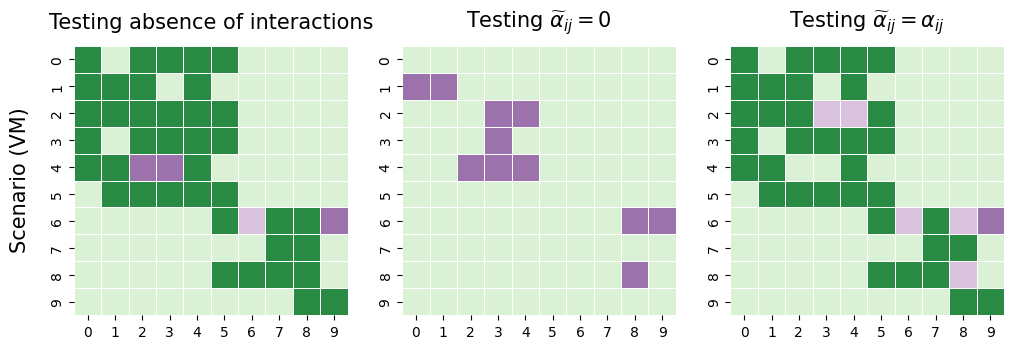

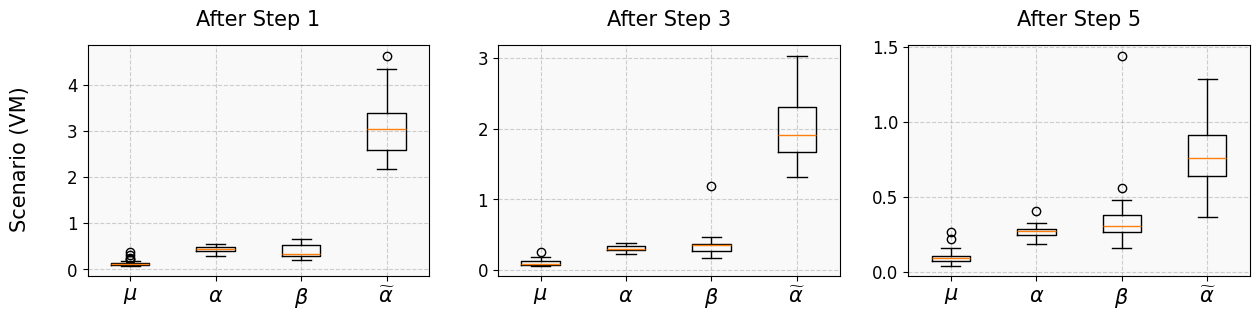

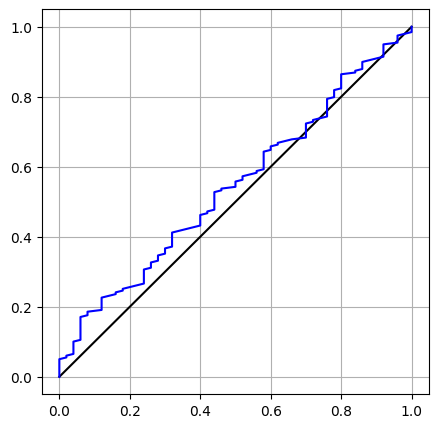

Average p-value: 0.5436555863429305


In [239]:
####### Plot test results #######

fig, axes = plt.subplots(1,3, figsize=(12, 3.5))

colors = ["#ff8a8e", "white", "#00ff2c"]
custom_cmap_real = LinearSegmentedColormap.from_list("custom_cmap", colors)
custom_cmap = ListedColormap(["#dbf1d6","#9b72ac", "#d9c2de", "#298a44"]) 

# Testing interactions 

interaction_test_matrix = vm_gvm_interaction_matrix
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 1, categorical_matrix)  # Undetected zero
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes[0],
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes[0].tick_params(axis='x')
axes[0].tick_params(axis='y')


# Testing VM interactions

test_matrix = vm_gvm_matrix_vm
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, test_matrix), 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, ~test_matrix), 1, categorical_matrix)  # Wrongly detected non-zero
categorical_matrix = np.where(np.logical_and(alpha_tilde != 0, test_matrix), 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(np.logical_and(alpha_tilde != 0,~test_matrix), 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes[1],
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes[1].tick_params(axis='x')
axes[1].tick_params(axis='y')


# Testing HP interactions

test_matrix = vm_gvm_matrix_hp
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == alpha, test_matrix), 0, categorical_matrix)  # Correct equal
categorical_matrix = np.where(np.logical_and(alpha_tilde == alpha, ~test_matrix), 1, categorical_matrix)  # Undetected equal
categorical_matrix = np.where(np.logical_and(alpha_tilde != alpha, test_matrix), 2, categorical_matrix)  # False equal detected
categorical_matrix = np.where(np.logical_and(alpha_tilde != alpha, ~test_matrix), 3, categorical_matrix)  # Correct non-equal

sns.heatmap(
    categorical_matrix,
    ax=axes[2],
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes[2].tick_params(axis='x')
axes[2].tick_params(axis='y')


titlesize = 15
pad = 13
axes[0].set_title(r"Testing absence of interactions", fontsize=titlesize, pad=pad)
axes[1].set_title(r"Testing $\widetilde{\alpha}_{ij} = 0$", fontsize=titlesize, pad=pad)
axes[2].set_title(r"Testing $\widetilde{\alpha}_{ij}=\alpha_{ij} $", fontsize=titlesize,pad=pad)
fig.text(0.08, 0.5,'Scenario (VM)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()


####### Error boxplots after each step #######

def relative_error_norm(estimation, true):
    n = len(true)
    if np.sum(true==0) == n*n:
        return np.linalg.norm(estimation)
    return (np.linalg.norm(estimation-true) / np.linalg.norm(true))
    
def compute_errors(multiple_estimations, mu, alpha, beta, alpha_tilde):
    mu_errors = [relative_error_norm(est[0], mu) for est in multiple_estimations]
    alpha_errors = [relative_error_norm(est[1], alpha) for est in multiple_estimations]
    beta_errors = [relative_error_norm(est[2], beta) for est in multiple_estimations]
    alpha_tilde_errors = [relative_error_norm(est[3], alpha_tilde) for est in multiple_estimations]

    return [mu_errors, alpha_errors, beta_errors, alpha_tilde_errors]

labels = [r'$\mu$', r'$\alpha$', r'$\beta$', r'$\widetilde{\alpha}$']

fig, ax = plt.subplots(1,3, figsize=(15,3))
titlesize = 15
xsize = 15
ysize = 12
pad = 14

data = compute_errors(vm_gvm_estimations_step1, mu, alpha, beta, alpha_tilde)
ax[0].boxplot(data, showfliers=True, tick_labels=labels)
ax[0].set_title('After Step 1')
ax[0].grid(True, linestyle='--', alpha=0.6)
ax[0].set_title('After Step 1', fontsize=titlesize, pad=pad)

data = compute_errors(vm_gvm_estimations_step3, mu, alpha, beta, alpha_tilde)
ax[1].boxplot(data, showfliers=True, tick_labels=labels)
ax[1].set_title('After Step 3')
ax[1].grid(True, linestyle='--', alpha=0.6)
ax[1].set_title('After Step 3', fontsize=titlesize, pad=pad)

data = compute_errors(vm_gvm_estimations_step5, mu, alpha, beta, alpha_tilde)
ax[2].boxplot(data, showfliers=True, tick_labels=labels)
ax[2].set_title('After Step 5')
ax[2].grid(True, linestyle='--', alpha=0.6)
ax[2].set_title('After Step 5', fontsize=titlesize, pad=pad)

for i in range(3):
    ax[i].tick_params(axis='x', labelsize=xsize)
    ax[i].tick_params(axis='y', labelsize=ysize)

for a in ax:
    a.set_facecolor('#f9f9f9')

fig.text(0.08, 0.5,'Scenario (VM)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()


####### P-values #######

nb_iterations = 50 # for resampling

fig,ax=plt.subplots(figsize=(5,5))
nb = 200
y = np.linspace(0, 1, nb)

values = np.array([np.sum(vm_gvm_pvalues <= yk) / nb_iterations for yk in y])

ax.plot(y, y,color='black')
ax.plot(values, y,color='blue')
ax.grid()
plt.show()

print('Average p-value:', np.mean(vm_gvm_pvalues))

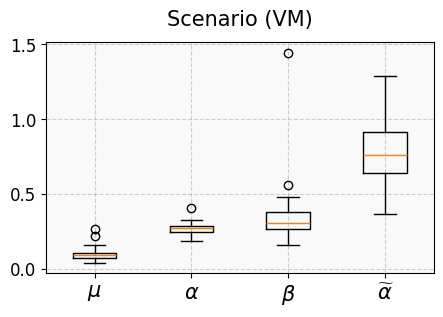

In [244]:
# just Step 5

labels = [r'$\mu$', r'$\alpha$', r'$\beta$', r'$\widetilde{\alpha}$']

fig, ax = plt.subplots(figsize=(5,3))
titlesize = 15
xsize = 15
ysize = 12
pad = 14

data = compute_errors(vm_gvm_estimations_step5, mu, alpha, beta, alpha_tilde)
ax.boxplot(data, showfliers=True, tick_labels=labels)
ax.set_title('After Step 5')
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_title('After Step 5', fontsize=titlesize, pad=pad)

ax.tick_params(axis='x', labelsize=xsize)
ax.tick_params(axis='y', labelsize=ysize)

ax.set_facecolor('#f9f9f9')
plt.title('Scenario (VM)',fontsize=15,pad=12)
plt.show()

### Under (HP)

In [243]:
hawkes_hp_est = ExponentialHawkesGVM(model='hp')
hawkes_hp_est.fit(times)
hawkes_hp_est.test_sparsity_alpha()
hawkes_hp_est.fit(times, each_realisation=False)

pvalues = hawkes_hp_est.pvalues(nb_iterations=nb_iterations, distribution='expon', method='cramervonmises', av_estimation=False)

#### Save all estimations

In [262]:
output_filename = "results_sim/scenario_vm_dim10_under_hp.txt"
with open(output_filename, "w") as f:
    f.write("vm_hp_estimations_step1 = [\n")
    for mu_est, alpha_est, beta_est in hawkes_hp_est.multiple_estimations:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())})),\n")
    f.write("]\n\n")
    
    f.write("vm_hp_final_estimation = (\n")
    mu_est, alpha_est, beta_est = hawkes_hp_est.estimation
    f.write(f"    np.array({repr(mu_est.tolist())}),\n")
    f.write(f"    np.array({repr(alpha_est.tolist())}),\n")
    f.write(f"    np.array({repr(beta_est.tolist())}),\n")
    f.write(")\n\n")

    f.write('vm_hp_interaction_matrix =')
    f.write(f'   np.array({repr(hawkes_hp_est.alpha_zero_coefficients.tolist())})\n') 
    f.write("\n")

    f.write("vm_hp_pvalues = np.array(\n")
    f.write(f"{repr(pvalues.tolist())}\n")
    f.write(")\n\n")


    

In [263]:
with open("results_sim/scenario_vm_dim10_under_hp.txt", "r") as file:
    file_content = file.read()
exec(file_content)

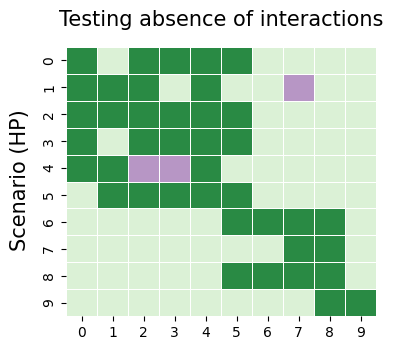

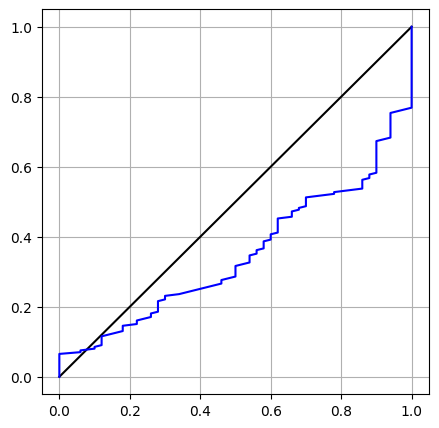

Average p-value: 0.3475815377485974


In [264]:
####### Plot test results #######

fig, axes = plt.subplots( figsize=(4, 3.5))

colors = ["#ff8a8e", "white", "#00ff2c"]
custom_cmap_real = LinearSegmentedColormap.from_list("custom_cmap", colors)
custom_cmap = ListedColormap(["#dbf1d6","#b796c5", "#e0cbe3", "#298a44"]) 

# Testing interactions 

interaction_test_matrix = vm_hp_interaction_matrix
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 1, categorical_matrix)  # Undetected zero
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes,
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes.tick_params(axis='x')
axes.tick_params(axis='y')


titlesize = 15
pad = 15
axes.set_title(r"Testing absence of interactions", fontsize=titlesize, pad=pad)
fig.text(0.01, 0.5,'Scenario (HP)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()



####### P-values #######

nb_iterations = 50 # for resampling

fig,ax=plt.subplots(figsize=(5,5))
nb = 200
y = np.linspace(0, 1, nb)

values = np.array([np.sum(vm_hp_pvalues <= yk) / nb_iterations for yk in y])

ax.plot(y, y,color='black')
ax.plot(values, y,color='blue')
ax.grid()
plt.show()

print('Average p-value:', np.mean(vm_hp_pvalues))

### Under (VM)

In [265]:
true_params = [mu, alpha, beta]
hawkes_vm = ExponentialHawkesGVM(model='vm')
hawkes_vm.d = d
hawkes_vm.times = times
hawkes_vm.nb_realisations = 25
hawkes_vm.estimation = true_params
pvals = hawkes_vm.pvalues(nb_iterations=50, av_estimation=False, method='cramervonmises', distribution='expon')
print('Pvalue with true params under vm:', np.mean(pvals))

Pvalue with true params under vm: 0.028253932619717897


In [266]:
hawkes_vm_est = ExponentialHawkesGVM(model='vm')
hawkes_vm_est.fit(times)
hawkes_vm_est.test_sparsity_alpha()
hawkes_vm_est.fit(times, each_realisation=False)
pvalues = hawkes_vm_est.pvalues(nb_iterations=nb_iterations, distribution='expon', method='cramervonmises', av_estimation=False)

#### Save all estimations

In [267]:
output_filename = "results_sim/scenario_vm_dim10_under_vm.txt"
with open(output_filename, "w") as f:
    f.write("vm_vm_estimations_step1 = [\n")
    for mu_est, alpha_est, beta_est in hawkes_vm_est.multiple_estimations:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())})),\n")
    f.write("]\n\n")
    
    f.write("vm_vm_final_estimation = (\n")
    mu_est, alpha_est, beta_est = hawkes_vm_est.estimation
    f.write(f"    np.array({repr(mu_est.tolist())}),\n")
    f.write(f"    np.array({repr(alpha_est.tolist())}),\n")
    f.write(f"    np.array({repr(beta_est.tolist())}),\n")
    f.write(")\n\n")

    f.write('vm_vm_interaction_matrix =')
    f.write(f'   np.array({repr(hawkes_vm_est.alpha_zero_coefficients.tolist())})\n') 
    f.write("\n")

    f.write("vm_vm_pvalues = np.array(\n")
    f.write(f"{repr(pvalues.tolist())}\n")
    f.write(")\n\n")


    

In [268]:
with open("results_sim/scenario_vm_dim10_under_vm.txt", "r") as file:
    file_content = file.read()
exec(file_content)

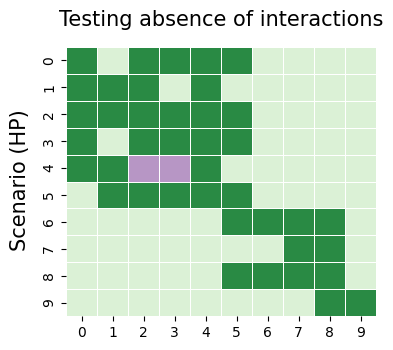

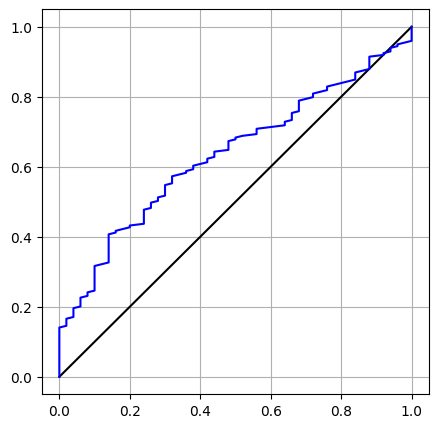

Average p-value: 0.6337816997933597


In [269]:
####### Plot test results #######

fig, axes = plt.subplots( figsize=(4, 3.5))

colors = ["#ff8a8e", "white", "#00ff2c"]
custom_cmap_real = LinearSegmentedColormap.from_list("custom_cmap", colors)
custom_cmap = ListedColormap(["#dbf1d6","#b796c5", "#e0cbe3", "#298a44"]) 

# Testing interactions 

interaction_test_matrix = vm_vm_interaction_matrix
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 1, categorical_matrix)  # Undetected zero
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes,
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes.tick_params(axis='x')
axes.tick_params(axis='y')


titlesize = 15
pad = 15
axes.set_title(r"Testing absence of interactions", fontsize=titlesize, pad=pad)
fig.text(0.01, 0.5,'Scenario (HP)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()



####### P-values #######

nb_iterations = 50 # for resampling

fig,ax=plt.subplots(figsize=(5,5))
nb = 200
y = np.linspace(0, 1, nb)

values = np.array([np.sum(vm_vm_pvalues <= yk) / nb_iterations for yk in y])

ax.plot(y, y,color='black')
ax.plot(values, y,color='blue')
ax.grid()
plt.show()

print('Average p-value:', np.mean(vm_vm_pvalues))

## Scenario (GVM)

In [270]:
####### Define parameters #######

d = 10

mu = np.array([1.0, 1.3, 1.2, 0.8, 0.5, 0.3, 1.1, 1.0, 0.3, 1.5])

alpha = np.array( [ [0.5, 0.0, 0.2, -0.8, 0.5, 0.7, 0.0, 0.0, 0.0, 0.0],
                    [1.0, -0.5, -0.2, 0.0, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0],
                    [0.2, -0.9, 0.7, 0.1, -0.1, 0.3, 0.0, 0.0, 0.0, 0.0],
                    [-0.4, 0.0, 1.2, -0.8, 0.2, 0.2, 0.0, 0.0, 0.0, 0.0],
                    [1.2, 0.3, 0.0, 0.0, 0.7, 0.0, 0.0, 0.0, 0.0, 0.0],
                    [0.0, -0.1, 1.0, -0.8, 0.1, 0.2, 0.0, 0.0, 0.0, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.5, -0.1, -0.2, -0.1, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.5, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.3, 0.3, 0.5, -0.1, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.4, 0.6] ])

beta = np.array([6.0, 3.0, 2.2, 3.6, 6.0, 1.4, 2.4, 2.0, 1.6, 2.4])

alpha_tilde = copy.deepcopy(alpha)
alpha_tilde[1,:] = np.zeros(d)
alpha_tilde[3,:] = np.zeros(d)
alpha_tilde[8,:] = np.zeros(d)

In [271]:
####### Simulate data #######

nb_realisations = 25
size = 10000

hawkes = ExponentialHawkesGVM(model='gvm', mu=mu, alpha=alpha, beta=beta, alpha_tilde=alpha_tilde)
times = hawkes.simulate(size=size, nb_realisations=nb_realisations)

In [272]:
### Save times ####

output_filename = "results_sim/times_dim10_gvm.txt"
with open(output_filename, "w") as f:
    f.write("times = ")
    f.write(f"    {times}")
    f.write("\n\n")

### Under (GVM)

In [273]:
####### Estimation procedure #######

# Step 1

hawkes = ExponentialHawkesGVM()
hawkes.fit(times)
estimations_step1 = copy.deepcopy(hawkes.multiple_estimations)

# Step 2

hawkes.test_absence_interactions() 

# Step 3

hawkes.fit(times)
estimations_step3 = copy.deepcopy(hawkes.multiple_estimations)

# Step 4

hawkes.tests_hp_vm()

# Step 5

# by averaging each estimation (to show boxplots of errors)
hawkes.fit(times)
estimations_step5 = copy.deepcopy(hawkes.multiple_estimations)

# by minimising sum of log-likelihoods (for p-values)
hawkes.fit(times, each_realisation=False)
estimation_step5 = copy.deepcopy(hawkes.estimation)

pvalues = hawkes.pvalues(nb_iterations=nb_iterations, distribution='expon', method='cramervonmises', av_estimation=False)

#### Save all estimations

In [277]:
output_filename = "results_sim/scenario_gvm_dim10_under_gvm.txt"
with open(output_filename, "w") as f:
    f.write("gvm_gvm_estimations_step1 = [\n")
    for mu_est, alpha_est, beta_est, alpha_tilde_est in estimations_step1:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_tilde_est.tolist())})),\n")
    f.write("]\n\n")
    
    f.write("gvm_gvm_estimations_step3 = [\n")
    for mu_est, alpha_est, beta_est, alpha_tilde_est in estimations_step3:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_tilde_est.tolist())})),\n")
    f.write("]\n\n")
    
    f.write("gvm_gvm_estimations_step5 = [\n")
    for mu_est, alpha_est, beta_est, alpha_tilde_est in estimations_step5:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_tilde_est.tolist())})),\n")
    f.write("]\n\n")

    f.write("gvm_gvm_final_estimation = (\n")
    mu_est, alpha_est, beta_est, alpha_tilde_est = estimation_step5
    f.write(f"    np.array({repr(mu_est.tolist())}),\n")
    f.write(f"    np.array({repr(alpha_est.tolist())}),\n")
    f.write(f"    np.array({repr(beta_est.tolist())}),\n")
    f.write(f"    np.array({repr(alpha_tilde_est.tolist())})\n")
    f.write(")\n\n")

    f.write('gvm_gvm_interaction_matrix =')
    f.write(f'   np.array({repr(hawkes.alpha_zero_coefficients.tolist())})\n') 
    f.write("\n")

    f.write('gvm_gvm_matrix_hp =')
    f.write(f'   np.array({repr(hawkes.equal_coefficients.tolist())})\n') 
    f.write("\n")

    f.write('gvm_gvm_matrix_vm =')
    f.write(f'   np.array({repr(hawkes.alpha_tilde_zero_coefficients.tolist())})\n') 
    f.write("\n")

    f.write("gvm_gvm_pvalues = np.array(\n")
    f.write(f"{repr(pvalues.tolist())}\n")
    f.write(")\n\n")


    

In [278]:
with open("results_sim/scenario_gvm_dim10_under_gvm.txt", "r") as file:
    file_content = file.read()
exec(file_content)

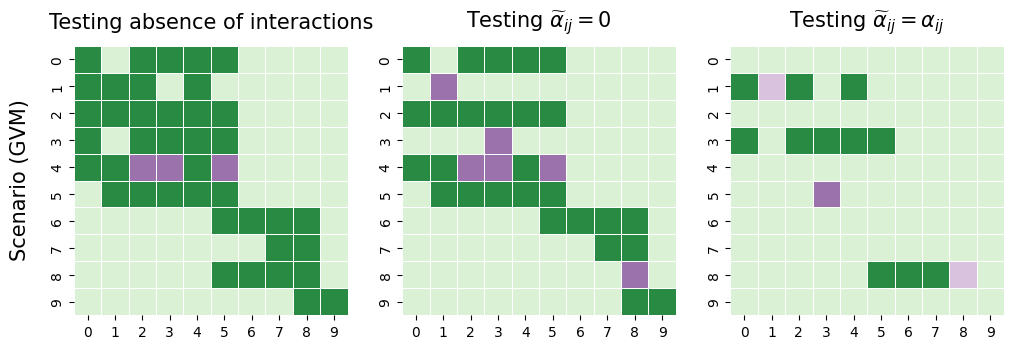

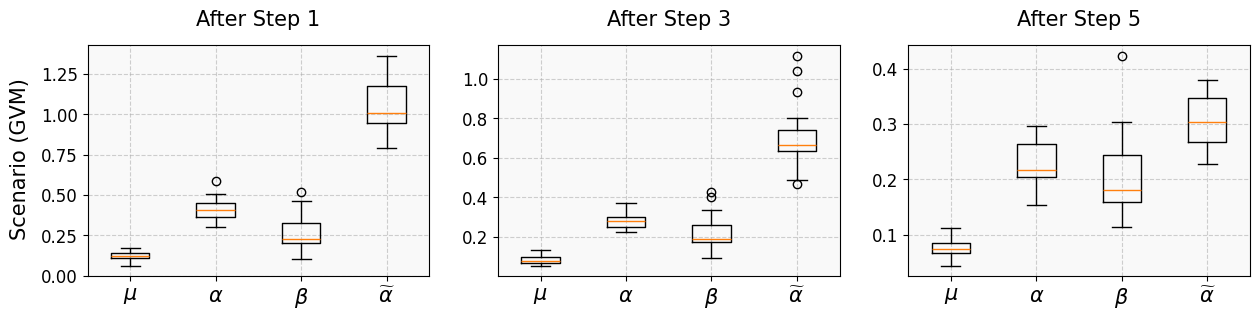

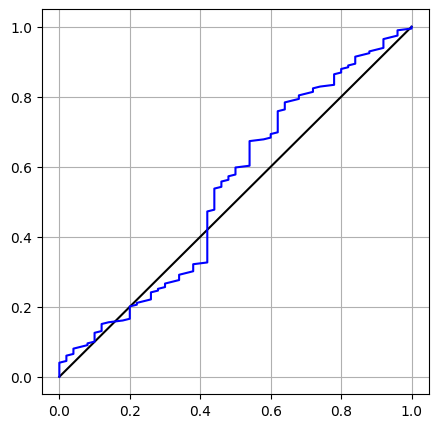

Average p-value: 0.5370447965317895


In [281]:
####### Plot test results #######

fig, axes = plt.subplots(1,3, figsize=(12, 3.5))

colors = ["#ff8a8e", "white", "#00ff2c"]
custom_cmap_real = LinearSegmentedColormap.from_list("custom_cmap", colors)
custom_cmap = ListedColormap(["#dbf1d6","#9b72ac", "#d9c2de", "#298a44"]) 

# Testing interactions 

interaction_test_matrix = gvm_gvm_interaction_matrix
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 1, categorical_matrix)  # Undetected zero
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes[0],
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes[0].tick_params(axis='x')
axes[0].tick_params(axis='y')


# Testing VM interactions

test_matrix = gvm_gvm_matrix_vm
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, test_matrix), 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, ~test_matrix), 1, categorical_matrix)  # Wrongly detected non-zero
categorical_matrix = np.where(np.logical_and(alpha_tilde != 0, test_matrix), 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(np.logical_and(alpha_tilde != 0,~test_matrix), 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes[1],
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes[1].tick_params(axis='x')
axes[1].tick_params(axis='y')


# Testing HP interactions

test_matrix = gvm_gvm_matrix_hp
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == alpha, test_matrix), 0, categorical_matrix)  # Correct equal
categorical_matrix = np.where(np.logical_and(alpha_tilde == alpha, ~test_matrix), 1, categorical_matrix)  # Undetected equal
categorical_matrix = np.where(np.logical_and(alpha_tilde != alpha, test_matrix), 2, categorical_matrix)  # False equal detected
categorical_matrix = np.where(np.logical_and(alpha_tilde != alpha, ~test_matrix), 3, categorical_matrix)  # Correct non-equal

sns.heatmap(
    categorical_matrix,
    ax=axes[2],
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes[2].tick_params(axis='x')
axes[2].tick_params(axis='y')


titlesize = 15
pad = 13
axes[0].set_title(r"Testing absence of interactions", fontsize=titlesize, pad=pad)
axes[1].set_title(r"Testing $\widetilde{\alpha}_{ij} = 0$", fontsize=titlesize, pad=pad)
axes[2].set_title(r"Testing $\widetilde{\alpha}_{ij}=\alpha_{ij} $", fontsize=titlesize,pad=pad)
fig.text(0.08, 0.5,'Scenario (GVM)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()


####### Error boxplots after each step #######

def relative_error_norm(estimation, true):
    n = len(true)
    if np.sum(true==0) == n*n:
        return np.linalg.norm(estimation)
    return (np.linalg.norm(estimation-true) / np.linalg.norm(true))
    
def compute_errors(multiple_estimations, mu, alpha, beta, alpha_tilde):
    mu_errors = [relative_error_norm(est[0], mu) for est in multiple_estimations]
    alpha_errors = [relative_error_norm(est[1], alpha) for est in multiple_estimations]
    beta_errors = [relative_error_norm(est[2], beta) for est in multiple_estimations]
    alpha_tilde_errors = [relative_error_norm(est[3], alpha_tilde) for est in multiple_estimations]

    return [mu_errors, alpha_errors, beta_errors, alpha_tilde_errors]

labels = [r'$\mu$', r'$\alpha$', r'$\beta$', r'$\widetilde{\alpha}$']

fig, ax = plt.subplots(1,3, figsize=(15,3))
titlesize = 15
xsize = 15
ysize = 12
pad = 14

data = compute_errors(gvm_gvm_estimations_step1, mu, alpha, beta, alpha_tilde)
ax[0].boxplot(data, showfliers=True, tick_labels=labels)
ax[0].set_title('After Step 1')
ax[0].grid(True, linestyle='--', alpha=0.6)
ax[0].set_title('After Step 1', fontsize=titlesize, pad=pad)

data = compute_errors(gvm_gvm_estimations_step3, mu, alpha, beta, alpha_tilde)
ax[1].boxplot(data, showfliers=True, tick_labels=labels)
ax[1].set_title('After Step 3')
ax[1].grid(True, linestyle='--', alpha=0.6)
ax[1].set_title('After Step 3', fontsize=titlesize, pad=pad)

data = compute_errors(gvm_gvm_estimations_step5, mu, alpha, beta, alpha_tilde)
ax[2].boxplot(data, showfliers=True, tick_labels=labels)
ax[2].set_title('After Step 5')
ax[2].grid(True, linestyle='--', alpha=0.6)
ax[2].set_title('After Step 5', fontsize=titlesize, pad=pad)

for i in range(3):
    ax[i].tick_params(axis='x', labelsize=xsize)
    ax[i].tick_params(axis='y', labelsize=ysize)

for a in ax:
    a.set_facecolor('#f9f9f9')

fig.text(0.08, 0.5,'Scenario (GVM)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()


####### P-values #######

nb_iterations = 50 # for resampling

fig,ax=plt.subplots(figsize=(5,5))
nb = 200
y = np.linspace(0, 1, nb)

values = np.array([np.sum(gvm_gvm_pvalues <= yk) / nb_iterations for yk in y])

ax.plot(y, y,color='black')
ax.plot(values, y,color='blue')
ax.grid()
plt.show()

print('Average p-value:', np.mean(gvm_gvm_pvalues))

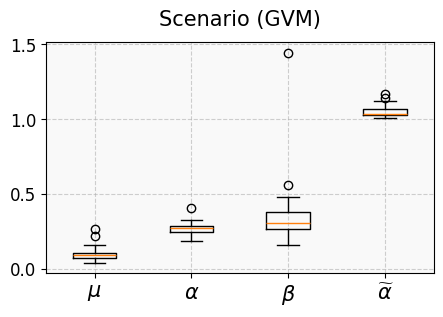

In [282]:
# just Step 5

labels = [r'$\mu$', r'$\alpha$', r'$\beta$', r'$\widetilde{\alpha}$']

fig, ax = plt.subplots(figsize=(5,3))
titlesize = 15
xsize = 15
ysize = 12
pad = 14

data = compute_errors(vm_gvm_estimations_step5, mu, alpha, beta, alpha_tilde)
ax.boxplot(data, showfliers=True, tick_labels=labels)
ax.set_title('After Step 5')
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_title('After Step 5', fontsize=titlesize, pad=pad)

ax.tick_params(axis='x', labelsize=xsize)
ax.tick_params(axis='y', labelsize=ysize)

ax.set_facecolor('#f9f9f9')
plt.title('Scenario (GVM)',fontsize=15,pad=12)
plt.show()

### Under (HP)

In [283]:
hawkes_hp_est = ExponentialHawkesGVM(model='hp')
hawkes_hp_est.fit(times)
hawkes_hp_est.test_sparsity_alpha()
hawkes_hp_est.fit(times, each_realisation=False)

pvalues = hawkes_hp_est.pvalues(nb_iterations=nb_iterations, distribution='expon', method='cramervonmises', av_estimation=False)

#### Save all estimations

In [284]:
output_filename = "results_sim/scenario_gvm_dim10_under_hp.txt"
with open(output_filename, "w") as f:
    f.write("gvm_hp_estimations_step1 = [\n")
    for mu_est, alpha_est, beta_est in hawkes_hp_est.multiple_estimations:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())})),\n")
    f.write("]\n\n")
    
    f.write("gvm_hp_final_estimation = (\n")
    mu_est, alpha_est, beta_est = hawkes_hp_est.estimation
    f.write(f"    np.array({repr(mu_est.tolist())}),\n")
    f.write(f"    np.array({repr(alpha_est.tolist())}),\n")
    f.write(f"    np.array({repr(beta_est.tolist())}),\n")
    f.write(")\n\n")

    f.write('gvm_hp_interaction_matrix =')
    f.write(f'   np.array({repr(hawkes_hp_est.alpha_zero_coefficients.tolist())})\n') 
    f.write("\n")

    f.write("gvm_hp_pvalues = np.array(\n")
    f.write(f"{repr(pvalues.tolist())}\n")
    f.write(")\n\n")


    

In [285]:
with open("results_sim/scenario_gvm_dim10_under_hp.txt", "r") as file:
    file_content = file.read()
exec(file_content)

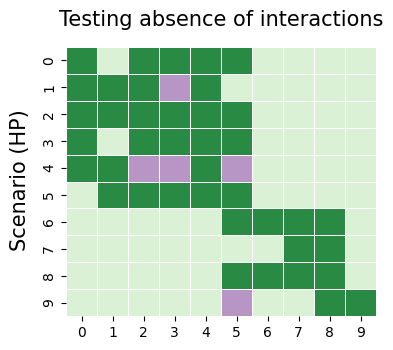

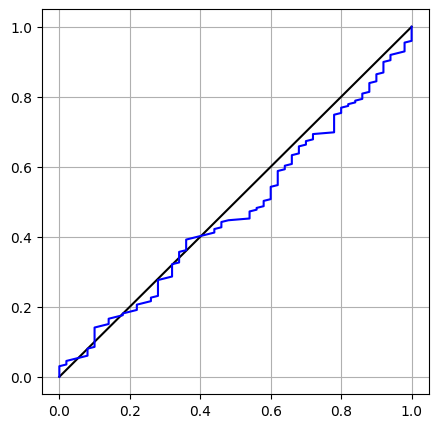

Average p-value: 0.47174157475502954


In [286]:
####### Plot test results #######

fig, axes = plt.subplots( figsize=(4, 3.5))

colors = ["#ff8a8e", "white", "#00ff2c"]
custom_cmap_real = LinearSegmentedColormap.from_list("custom_cmap", colors)
custom_cmap = ListedColormap(["#dbf1d6","#b796c5", "#e0cbe3", "#298a44"]) 

# Testing interactions 

interaction_test_matrix = gvm_hp_interaction_matrix
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 1, categorical_matrix)  # Undetected zero
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes,
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes.tick_params(axis='x')
axes.tick_params(axis='y')


titlesize = 15
pad = 15
axes.set_title(r"Testing absence of interactions", fontsize=titlesize, pad=pad)
fig.text(0.01, 0.5,'Scenario (HP)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()



####### P-values #######

nb_iterations = 50 # for resampling

fig,ax=plt.subplots(figsize=(5,5))
nb = 200
y = np.linspace(0, 1, nb)

values = np.array([np.sum(gvm_hp_pvalues <= yk) / nb_iterations for yk in y])

ax.plot(y, y,color='black')
ax.plot(values, y,color='blue')
ax.grid()
plt.show()

print('Average p-value:', np.mean(gvm_hp_pvalues))

### Under (VM)

In [287]:
true_params = [mu, alpha, beta]
hawkes_vm = ExponentialHawkesGVM(model='vm')
hawkes_vm.d = d
hawkes_vm.times = times
hawkes_vm.nb_realisations = 25
hawkes_vm.estimation = true_params
pvals = hawkes_vm.pvalues(nb_iterations=50, av_estimation=False, method='cramervonmises', distribution='expon')
print('Pvalue with true params under vm:', np.mean(pvals))

Pvalue with true params under vm: 1.6746154789526457e-08


In [288]:
hawkes_vm_est = ExponentialHawkesGVM(model='vm')
hawkes_vm_est.fit(times)
hawkes_vm_est.test_sparsity_alpha()
hawkes_vm_est.fit(times, each_realisation=False)
pvalues = hawkes_vm_est.pvalues(nb_iterations=nb_iterations, distribution='expon', method='cramervonmises', av_estimation=False)

#### Save all estimations

In [289]:
output_filename = "results_sim/scenario_gvm_dim10_under_vm.txt"
with open(output_filename, "w") as f:
    f.write("gvm_vm_estimations_step1 = [\n")
    for mu_est, alpha_est, beta_est in hawkes_vm_est.multiple_estimations:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())})),\n")
    f.write("]\n\n")
    
    f.write("gvm_vm_final_estimation = (\n")
    mu_est, alpha_est, beta_est = hawkes_vm_est.estimation
    f.write(f"    np.array({repr(mu_est.tolist())}),\n")
    f.write(f"    np.array({repr(alpha_est.tolist())}),\n")
    f.write(f"    np.array({repr(beta_est.tolist())}),\n")
    f.write(")\n\n")

    f.write('gvm_vm_interaction_matrix =')
    f.write(f'   np.array({repr(hawkes_vm_est.alpha_zero_coefficients.tolist())})\n') 
    f.write("\n")

    f.write("gvm_vm_pvalues = np.array(\n")
    f.write(f"{repr(pvalues.tolist())}\n")
    f.write(")\n\n")


    

In [290]:
with open("results_sim/scenario_gvm_dim10_under_vm.txt", "r") as file:
    file_content = file.read()
exec(file_content)

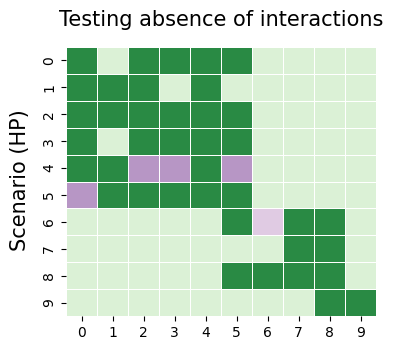

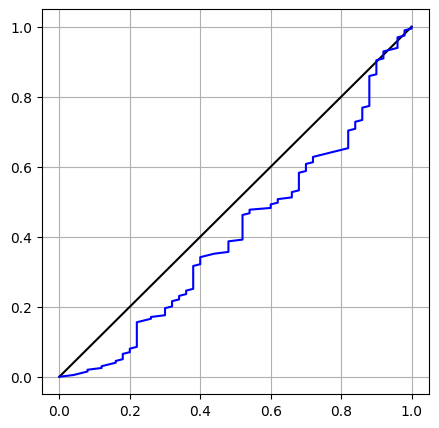

Average p-value: 0.4116748375847637


In [291]:
####### Plot test results #######

fig, axes = plt.subplots( figsize=(4, 3.5))

colors = ["#ff8a8e", "white", "#00ff2c"]
custom_cmap_real = LinearSegmentedColormap.from_list("custom_cmap", colors)
custom_cmap = ListedColormap(["#dbf1d6","#b796c5", "#e0cbe3", "#298a44"]) 

# Testing interactions 

interaction_test_matrix = gvm_vm_interaction_matrix
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 1, categorical_matrix)  # Undetected zero
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes,
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes.tick_params(axis='x')
axes.tick_params(axis='y')


titlesize = 15
pad = 15
axes.set_title(r"Testing absence of interactions", fontsize=titlesize, pad=pad)
fig.text(0.01, 0.5,'Scenario (HP)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()



####### P-values #######

nb_iterations = 50 # for resampling

fig,ax=plt.subplots(figsize=(5,5))
nb = 200
y = np.linspace(0, 1, nb)

values = np.array([np.sum(gvm_vm_pvalues <= yk) / nb_iterations for yk in y])

ax.plot(y, y,color='black')
ax.plot(values, y,color='blue')
ax.grid()
plt.show()

print('Average p-value:', np.mean(gvm_vm_pvalues))

## Scenario (HP-short-mem)

In [2]:
####### Define parameters #######

d = 10

mu = np.array([1.0, 1.3, 1.2, 0.8, 0.5, 0.3, 1.1, 1.0, 0.3, 1.5])

alpha = np.array( [ [0.5, 0.0, 0.2, -0.8, 0.5, 0.7, 0.0, 0.0, 0.0, 0.0],
                    [1.0, -0.5, -0.2, 0.0, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0],
                    [0.2, -0.9, 0.7, 0.1, -0.1, 0.3, 0.0, 0.0, 0.0, 0.0],
                    [-0.4, 0.0, 1.2, -0.8, 0.2, 0.2, 0.0, 0.0, 0.0, 0.0],
                    [1.2, 0.3, 0.0, 0.0, 0.7, 0.0, 0.0, 0.0, 0.0, 0.0],
                    [0.0, -0.1, 1.0, -0.8, 0.1, 0.2, 0.0, 0.0, 0.0, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.5, -0.1, -0.2, -0.1, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.5, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.3, 0.3, 0.5, -0.1, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.4, 0.6] ])

beta = 10*np.array([6.0, 3.0, 2.2, 3.6, 6.0, 1.4, 2.4, 2.0, 1.6, 2.4])

alpha_tilde = copy.deepcopy(alpha)

In [3]:
####### Simulate data #######

nb_realisations = 25
size = 10000

hawkes = ExponentialHawkesGVM(model='gvm', mu=mu, alpha=alpha, beta=beta, alpha_tilde=alpha_tilde)
times = hawkes.simulate(size=size, nb_realisations=nb_realisations)

In [4]:
### Save times ####

output_filename = "results_sim/times_dim10_hp_short_mem.txt"
with open(output_filename, "w") as f:
    f.write("times = ")
    f.write(f"    {times}")
    f.write("\n\n")

### Under (GVM)

In [6]:
####### Estimation procedure #######

# Step 1

hawkes = ExponentialHawkesGVM()
hawkes.fit(times)
estimations_step1 = copy.deepcopy(hawkes.multiple_estimations)

# Step 2

hawkes.test_absence_interactions() 

# Step 3

hawkes.fit(times)
estimations_step3 = copy.deepcopy(hawkes.multiple_estimations)

# Step 4

hawkes.tests_hp_vm()

# Step 5

# by averaging each estimation (to show boxplots of errors)
hawkes.fit(times)
estimations_step5 = copy.deepcopy(hawkes.multiple_estimations)

# by minimising sum of log-likelihoods (for p-values)
hawkes.fit(times, each_realisation=False)
estimation_step5 = copy.deepcopy(hawkes.estimation)
nb_iterations=50
pvalues = hawkes.pvalues(nb_iterations=nb_iterations, distribution='expon', method='cramervonmises', av_estimation=False)

#### Save all estimations

In [7]:
output_filename = "results_sim/scenario_hp_short_mem_dim10_under_gvm.txt"
with open(output_filename, "w") as f:
    f.write("hp_short_mem_gvm_estimations_step1 = [\n")
    for mu_est, alpha_est, beta_est, alpha_tilde_est in estimations_step1:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_tilde_est.tolist())})),\n")
    f.write("]\n\n")
    
    f.write("hp_short_mem_gvm_estimations_step3 = [\n")
    for mu_est, alpha_est, beta_est, alpha_tilde_est in estimations_step3:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_tilde_est.tolist())})),\n")
    f.write("]\n\n")
    
    f.write("hp_short_mem_gvm_estimations_step5 = [\n")
    for mu_est, alpha_est, beta_est, alpha_tilde_est in estimations_step5:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_tilde_est.tolist())})),\n")
    f.write("]\n\n")

    f.write("hp_short_mem_gvm_final_estimation = (\n")
    mu_est, alpha_est, beta_est, alpha_tilde_est = estimation_step5
    f.write(f"    np.array({repr(mu_est.tolist())}),\n")
    f.write(f"    np.array({repr(alpha_est.tolist())}),\n")
    f.write(f"    np.array({repr(beta_est.tolist())}),\n")
    f.write(f"    np.array({repr(alpha_tilde_est.tolist())})\n")
    f.write(")\n\n")

    f.write('hp_short_mem_gvm_interaction_matrix =')
    f.write(f'   np.array({repr(hawkes.alpha_zero_coefficients.tolist())})\n') 
    f.write("\n")

    f.write('hp_short_mem_gvm_matrix_hp =')
    f.write(f'   np.array({repr(hawkes.equal_coefficients.tolist())})\n') 
    f.write("\n")

    f.write('hp_short_mem_gvm_matrix_vm =')
    f.write(f'   np.array({repr(hawkes.alpha_tilde_zero_coefficients.tolist())})\n') 
    f.write("\n")

    f.write("hp_short_mem_gvm_pvalues = np.array(\n")
    f.write(f"{repr(pvalues.tolist())}\n")
    f.write(")\n\n")


    

In [8]:
with open("results_sim/scenario_hp_short_mem_dim10_under_gvm.txt", "r") as file:
    file_content = file.read()
exec(file_content)

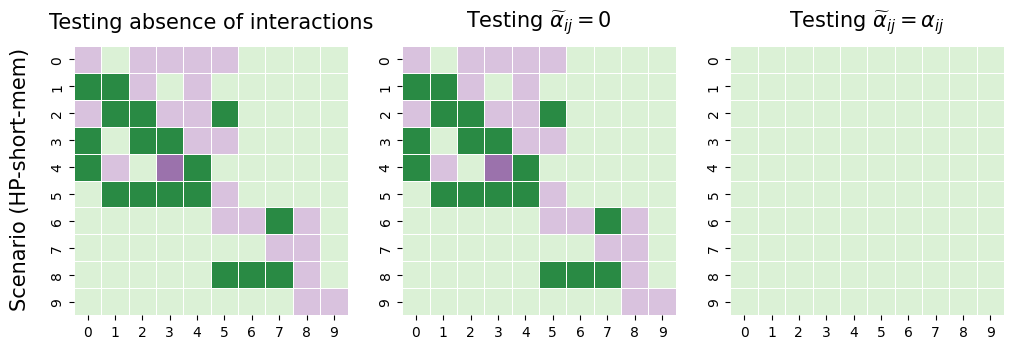

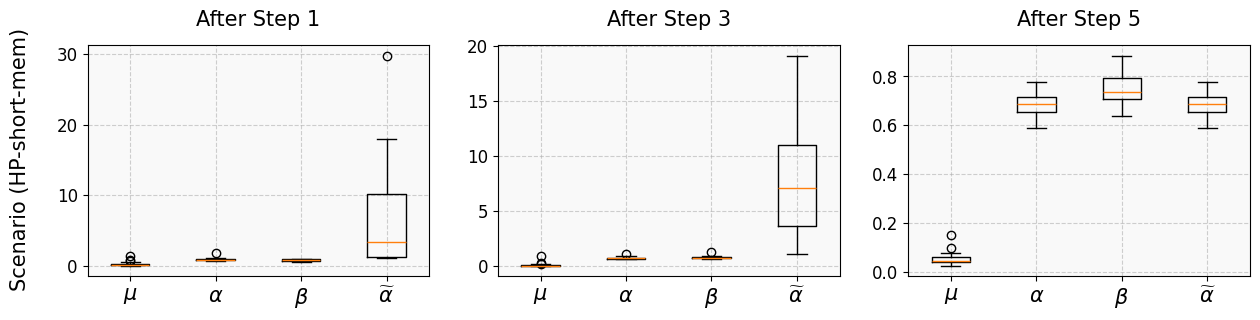

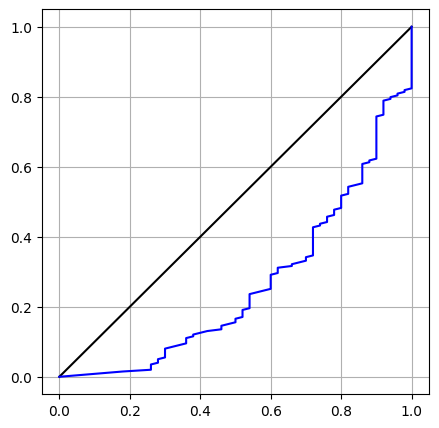

Average p-value: 0.2613204979959024


In [9]:
####### Plot test results #######

fig, axes = plt.subplots(1,3, figsize=(12, 3.5))

colors = ["#ff8a8e", "white", "#00ff2c"]
custom_cmap_real = LinearSegmentedColormap.from_list("custom_cmap", colors)
custom_cmap = ListedColormap(["#dbf1d6","#9b72ac", "#d9c2de", "#298a44"]) 

# Testing interactions 

interaction_test_matrix = hp_short_mem_gvm_interaction_matrix
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 1, categorical_matrix)  # Undetected zero
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes[0],
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes[0].tick_params(axis='x')
axes[0].tick_params(axis='y')


# Testing VM interactions

test_matrix = hp_short_mem_gvm_matrix_vm
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, test_matrix), 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, ~test_matrix), 1, categorical_matrix)  # Wrongly detected non-zero
categorical_matrix = np.where(np.logical_and(alpha_tilde != 0, test_matrix), 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(np.logical_and(alpha_tilde != 0,~test_matrix), 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes[1],
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes[1].tick_params(axis='x')
axes[1].tick_params(axis='y')


# Testing HP interactions

test_matrix = hp_short_mem_gvm_matrix_hp
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == alpha, test_matrix), 0, categorical_matrix)  # Correct equal
categorical_matrix = np.where(np.logical_and(alpha_tilde == alpha, ~test_matrix), 1, categorical_matrix)  # Undetected equal
categorical_matrix = np.where(np.logical_and(alpha_tilde != alpha, test_matrix), 2, categorical_matrix)  # False equal detected
categorical_matrix = np.where(np.logical_and(alpha_tilde != alpha, ~test_matrix), 3, categorical_matrix)  # Correct non-equal

sns.heatmap(
    categorical_matrix,
    ax=axes[2],
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes[2].tick_params(axis='x')
axes[2].tick_params(axis='y')


titlesize = 15
pad = 13
axes[0].set_title(r"Testing absence of interactions", fontsize=titlesize, pad=pad)
axes[1].set_title(r"Testing $\widetilde{\alpha}_{ij} = 0$", fontsize=titlesize, pad=pad)
axes[2].set_title(r"Testing $\widetilde{\alpha}_{ij}=\alpha_{ij} $", fontsize=titlesize,pad=pad)
fig.text(0.08, 0.5,'Scenario (HP-short-mem)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()


####### Error boxplots after each step #######

def relative_error_norm(estimation, true):
    n = len(true)
    if np.sum(true==0) == n*n:
        return np.linalg.norm(estimation)
    return (np.linalg.norm(estimation-true) / np.linalg.norm(true))
    
def compute_errors(multiple_estimations, mu, alpha, beta, alpha_tilde):
    mu_errors = [relative_error_norm(est[0], mu) for est in multiple_estimations]
    alpha_errors = [relative_error_norm(est[1], alpha) for est in multiple_estimations]
    beta_errors = [relative_error_norm(est[2], beta) for est in multiple_estimations]
    alpha_tilde_errors = [relative_error_norm(est[3], alpha_tilde) for est in multiple_estimations]

    return [mu_errors, alpha_errors, beta_errors, alpha_tilde_errors]

labels = [r'$\mu$', r'$\alpha$', r'$\beta$', r'$\widetilde{\alpha}$']

fig, ax = plt.subplots(1,3, figsize=(15,3))
titlesize = 15
xsize = 15
ysize = 12
pad = 14

data = compute_errors(hp_short_mem_gvm_estimations_step1, mu, alpha, beta, alpha_tilde)
ax[0].boxplot(data, showfliers=True, tick_labels=labels)
ax[0].set_title('After Step 1')
ax[0].grid(True, linestyle='--', alpha=0.6)
ax[0].set_title('After Step 1', fontsize=titlesize, pad=pad)

data = compute_errors(hp_short_mem_gvm_estimations_step3, mu, alpha, beta, alpha_tilde)
ax[1].boxplot(data, showfliers=True, tick_labels=labels)
ax[1].set_title('After Step 3')
ax[1].grid(True, linestyle='--', alpha=0.6)
ax[1].set_title('After Step 3', fontsize=titlesize, pad=pad)

data = compute_errors(hp_short_mem_gvm_estimations_step5, mu, alpha, beta, alpha_tilde)
ax[2].boxplot(data, showfliers=True, tick_labels=labels)
ax[2].set_title('After Step 5')
ax[2].grid(True, linestyle='--', alpha=0.6)
ax[2].set_title('After Step 5', fontsize=titlesize, pad=pad)

for i in range(3):
    ax[i].tick_params(axis='x', labelsize=xsize)
    ax[i].tick_params(axis='y', labelsize=ysize)

for a in ax:
    a.set_facecolor('#f9f9f9')

fig.text(0.08, 0.5,'Scenario (HP-short-mem)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()


####### P-values #######

nb_iterations = 50 # for resampling

fig,ax=plt.subplots(figsize=(5,5))
nb = 200
y = np.linspace(0, 1, nb)

values = np.array([np.sum(hp_short_mem_gvm_pvalues <= yk) / nb_iterations for yk in y])

ax.plot(y, y,color='black')
ax.plot(values, y,color='blue')
ax.grid()
plt.show()

print('Average p-value:', np.mean(hp_short_mem_gvm_pvalues))

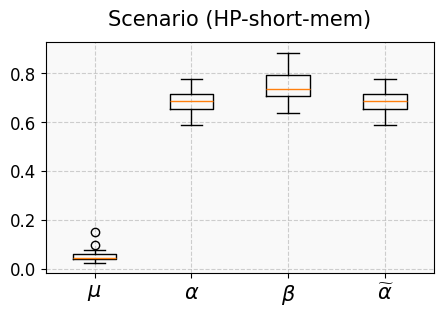

In [10]:
# just Step 5

labels = [r'$\mu$', r'$\alpha$', r'$\beta$', r'$\widetilde{\alpha}$']

fig, ax = plt.subplots(figsize=(5,3))
titlesize = 15
xsize = 15
ysize = 12
pad = 14

data = compute_errors(hp_short_mem_gvm_estimations_step5, mu, alpha, beta, alpha_tilde)
ax.boxplot(data, showfliers=True, tick_labels=labels)
ax.set_title('After Step 5')
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_title('After Step 5', fontsize=titlesize, pad=pad)

ax.tick_params(axis='x', labelsize=xsize)
ax.tick_params(axis='y', labelsize=ysize)

ax.set_facecolor('#f9f9f9')
plt.title('Scenario (HP-short-mem)',fontsize=15,pad=12)
plt.show()

### Under (HP)

In [11]:
hawkes_hp_est = ExponentialHawkesGVM(model='hp')
hawkes_hp_est.fit(times)
hawkes_hp_est.test_sparsity_alpha()
hawkes_hp_est.fit(times, each_realisation=False)

pvalues = hawkes_hp_est.pvalues(nb_iterations=nb_iterations, distribution='expon', method='cramervonmises', av_estimation=False)

#### Save all estimations

In [12]:
output_filename = "results_sim/scenario_hp_short_mem_dim10_under_hp.txt"
with open(output_filename, "w") as f:
    f.write("hp_short_mem_hp_estimations_step1 = [\n")
    for mu_est, alpha_est, beta_est in hawkes_hp_est.multiple_estimations:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())})),\n")
    f.write("]\n\n")
    
    f.write("hp_short_mem_hp_final_estimation = (\n")
    mu_est, alpha_est, beta_est = hawkes_hp_est.estimation
    f.write(f"    np.array({repr(mu_est.tolist())}),\n")
    f.write(f"    np.array({repr(alpha_est.tolist())}),\n")
    f.write(f"    np.array({repr(beta_est.tolist())}),\n")
    f.write(")\n\n")

    f.write('hp_short_mem_hp_interaction_matrix =')
    f.write(f'   np.array({repr(hawkes_hp_est.alpha_zero_coefficients.tolist())})\n') 
    f.write("\n")

    f.write("hp_short_mem_hp_pvalues = np.array(\n")
    f.write(f"{repr(pvalues.tolist())}\n")
    f.write(")\n\n")


    

In [13]:
with open("results_sim/scenario_hp_short_mem_dim10_under_hp.txt", "r") as file:
    file_content = file.read()
exec(file_content)

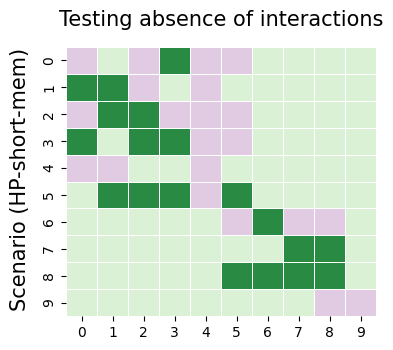

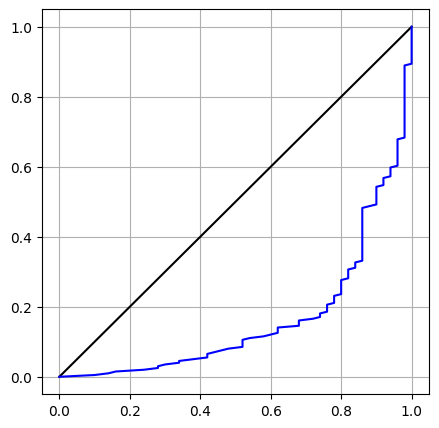

Average p-value: 0.16314946816080844


In [14]:
####### Plot test results #######

fig, axes = plt.subplots( figsize=(4, 3.5))

colors = ["#ff8a8e", "white", "#00ff2c"]
custom_cmap_real = LinearSegmentedColormap.from_list("custom_cmap", colors)
custom_cmap = ListedColormap(["#dbf1d6","#b796c5", "#e0cbe3", "#298a44"]) 

# Testing interactions 

interaction_test_matrix = hp_short_mem_hp_interaction_matrix
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 1, categorical_matrix)  # Undetected zero
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes,
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes.tick_params(axis='x')
axes.tick_params(axis='y')


titlesize = 15
pad = 15
axes.set_title(r"Testing absence of interactions", fontsize=titlesize, pad=pad)
fig.text(0.01, 0.5,'Scenario (HP-short-mem)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()



####### P-values #######

nb_iterations = 50 # for resampling

fig,ax=plt.subplots(figsize=(5,5))
nb = 200
y = np.linspace(0, 1, nb)

values = np.array([np.sum(hp_short_mem_hp_pvalues <= yk) / nb_iterations for yk in y])

ax.plot(y, y,color='black')
ax.plot(values, y,color='blue')
ax.grid()
plt.show()

print('Average p-value:', np.mean(hp_short_mem_hp_pvalues))

### Under (VM)

In [15]:
true_params = [mu, alpha, beta]
hawkes_vm = ExponentialHawkesGVM(model='vm')
hawkes_vm.d = d
hawkes_vm.times = times
hawkes_vm.nb_realisations = 25
hawkes_vm.estimation = true_params
pvals = hawkes_vm.pvalues(nb_iterations=50, av_estimation=False, method='cramervonmises', distribution='expon')
print('Pvalue with true params under vm:', np.mean(pvals))

Pvalue with true params under vm: 0.3345276605056675


In [16]:
hawkes_vm_est = ExponentialHawkesGVM(model='vm')
hawkes_vm_est.fit(times)
hawkes_vm_est.test_sparsity_alpha()
hawkes_vm_est.fit(times, each_realisation=False)
pvalues = hawkes_vm_est.pvalues(nb_iterations=nb_iterations, distribution='expon', method='cramervonmises', av_estimation=False)

#### Save all estimations

In [17]:
output_filename = "results_sim/scenario_hp_short_mem_dim10_under_vm.txt"
with open(output_filename, "w") as f:
    f.write("hp_short_mem_vm_estimations_step1 = [\n")
    for mu_est, alpha_est, beta_est in hawkes_vm_est.multiple_estimations:
        f.write(f"    (np.array({repr(mu_est.tolist())}),\n")
        f.write(f"     np.array({repr(alpha_est.tolist())}),\n")
        f.write(f"     np.array({repr(beta_est.tolist())})),\n")
    f.write("]\n\n")
    
    f.write("hp_short_mem_vm_final_estimation = (\n")
    mu_est, alpha_est, beta_est = hawkes_vm_est.estimation
    f.write(f"    np.array({repr(mu_est.tolist())}),\n")
    f.write(f"    np.array({repr(alpha_est.tolist())}),\n")
    f.write(f"    np.array({repr(beta_est.tolist())}),\n")
    f.write(")\n\n")

    f.write('hp_short_mem_vm_interaction_matrix =')
    f.write(f'   np.array({repr(hawkes_vm_est.alpha_zero_coefficients.tolist())})\n') 
    f.write("\n")

    f.write("hp_short_mem_vm_pvalues = np.array(\n")
    f.write(f"{repr(pvalues.tolist())}\n")
    f.write(")\n\n")


    

In [18]:
with open("results_sim/scenario_hp_short_mem_dim10_under_vm.txt", "r") as file:
    file_content = file.read()
exec(file_content)

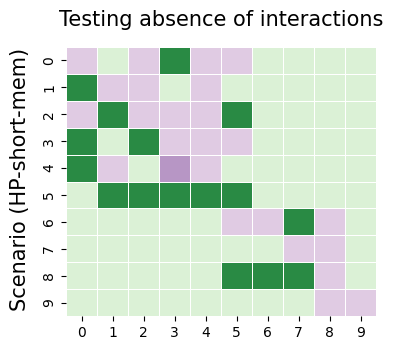

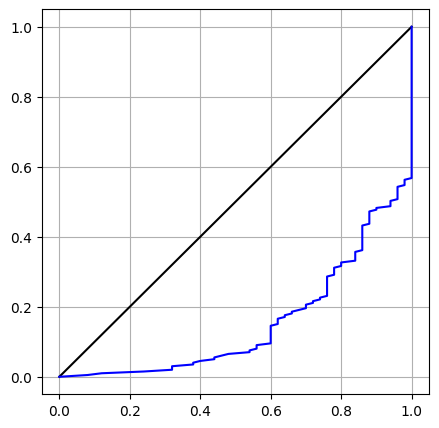

Average p-value: 0.1526028119133619


In [20]:
####### Plot test results #######

fig, axes = plt.subplots( figsize=(4, 3.5))

colors = ["#ff8a8e", "white", "#00ff2c"]
custom_cmap_real = LinearSegmentedColormap.from_list("custom_cmap", colors)
custom_cmap = ListedColormap(["#dbf1d6","#b796c5", "#e0cbe3", "#298a44"]) 

# Testing interactions 

interaction_test_matrix = hp_short_mem_vm_interaction_matrix
categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 1, categorical_matrix)  # Undetected zero
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_test_matrix, 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_test_matrix, 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes,
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes.tick_params(axis='x')
axes.tick_params(axis='y')


titlesize = 15
pad = 15
axes.set_title(r"Testing absence of interactions", fontsize=titlesize, pad=pad)
fig.text(0.01, 0.5,'Scenario (HP-short-mem)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()



####### P-values #######

nb_iterations = 50 # for resampling

fig,ax=plt.subplots(figsize=(5,5))
nb = 200
y = np.linspace(0, 1, nb)

values = np.array([np.sum(hp_short_mem_vm_pvalues <= yk) / nb_iterations for yk in y])

ax.plot(y, y,color='black')
ax.plot(values, y,color='blue')
ax.grid()
plt.show()

print('Average p-value:', np.mean(hp_short_mem_vm_pvalues))